## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob, os
from tqdm import tqdm

def compile_results(path,cases,max_run_num,filename="Broadcast_Metrics.csv"):
    """
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    max_run_num is the max run number to ider
    """
    df_list = []
    for case in cases:
        scenarios = glob.glob(os.path.join(path, case, "*"))
        for scenario in scenarios:
            df = pd.read_csv(os.path.join(scenario, filename))
            df = df.loc[df["Run"]<=max_run_num]
            df["Scenario"] = scenario.split("/")[-1]
            df_list.append(df)
    return pd.concat(df_list)

def compile_results_range(path,cases,start_run_num,end_run_num,filename="Broadcast_Metrics.csv"):
    """
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    max_run_num is the max run number to ider
    """
    df_list = []
    for case in cases:
        scenarios = glob.glob(os.path.join(path, case, "*"))
        for scenario in scenarios:
            df = pd.read_csv(os.path.join(scenario, filename))
            df = df.loc[(df["Run"]>=start_run_num) & (df["Run"]<=end_run_num)]
            df["Scenario"] = scenario.split("/")[-1]
            df_list.append(df)
    return pd.concat(df_list)

def compile_results_filtered(path,cases,max_run_num,filter_df,filename="Broadcast_Metrics.csv"):
    """
    Modified: to filter runs listed in filter_df, with columns (Height, USI, Bit_Rate, UAV_Speed, Run)
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    max_run_num is the max run number to ider
    """
    df_list = []
    for case in cases:
        scenarios = glob.glob(os.path.join(path, case, "*"))
        for scenario in scenarios:
            scenario_params = scenario.split('_')
            usi = float([x for x in scenario_params if "UAVSendingInterval" in x][0].split('-')[-1])
            uav_speed = float([x for x in scenario_params if "UAVSpeed" in x][0].split('-')[-1])
            height = float([x for x in scenario_params if "Height" in x][0].split('-')[-1])
            bitrate = float([x for x in scenario_params if "BitRate" in x][0].split('-')[-1])
            runs_to_filter = filter_df.loc[(filter_df["Height"]==height)&(filter_df["USI"]==usi)&
                                           (filter_df["Bit_Rate"]==bitrate)&(filter_df["UAV_Speed"]==uav_speed)]

            df = pd.read_csv(os.path.join(scenario, filename))
            df = df.loc[df["Run"]<=max_run_num]
            df = df.loc[~df["Run"].isin(runs_to_filter["Run"].values)]
            df["Scenario"] = scenario.split("/")[-1]
            df_list.append(df)
    return pd.concat(df_list)


## Plot Box Plots of Dmax

Text(0.5, 0, 'USI (ms)')

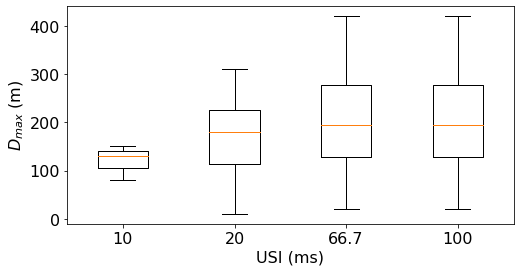

In [8]:
dmax_usi_10 = [130,150,80]
dmax_usi_20 = [200,270,310,160,210,120,90,10]
dmax_usi_667 = [250,360,420,170,220,140,90,20]
dmax_usi_100 = [250,360,420,170,220,140,90,20]

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([dmax_usi_10, dmax_usi_20, dmax_usi_667, dmax_usi_100], showmeans=False)
ax.set_ylabel('$D_{max}$ (m)', fontsize=16)
# ax.set_ylim(-1,105)
ax.set_xticklabels(["10", "20", "66.7", "100"], fontsize=16)
ax.set_xlabel("USI (ms)", fontsize=16)

### Plot Metrics for Various Schemes

#### For No GCS

In [2]:
# Plot Median DL Reliability and Media UPRR

MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_{}_Interference_new"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
rel_th = 0.90 # For getting percentage of runs above 90%
dmax_df = pd.read_csv("/home/research-student/omnet-fanet/data-processing-scripts/manual_control_max_hdist/Dmax_RelTh999_Simulated_Reliability_v3_10e5.csv")
SWITCH_DETAILS = "/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/obj3_scenario_script_new/{}/Switch_Details.csv"
bitrate_2_usi_index = {6.5: 0, 13: 1, 19.5: 2, 26: 3, 39: 4, 52: 5, 58.5: 6, 65: 7}

# manual_90 = []
# waypoint_90 = []
# fp_90 = []
# dv_90 = []
# pm_90 = []
# pm_gcs_90 = []

manual_med_rel = []
waypoint_med_rel = []
fp_25_med_rel = []
fp_50_med_rel = []
fp_100_med_rel = []
dv_med_rel = []
pm_med_rel = []
pm_gcs_med_rel = []

manual_med_ul_rel = []
waypoint_med_ul_rel = []
fp_25_med_ul_rel = []
fp_50_med_ul_rel = []
fp_100_med_ul_rel = []
dv_med_ul_rel = []
pm_med_ul_rel = []
pm_gcs_med_ul_rel = []

fp_25_med_uprr = []
fp_50_med_uprr = []
fp_100_med_uprr = []
dv_med_uprr = []
pm_med_uprr = []
pm_gcs_med_uprr = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"

    """ Compile without filtering runs that switched too late (1 sec away from max time based on D_max) """
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Simulation_Results.csv")
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM)
    '''For Custom Run Num Range'''
    manual_df = compile_results_range(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Simulation_Results.csv")
    waypoint_df = compile_results_range(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)

    """ Compile, filtering runs that switched too late (1 sec away from max time based on D_max) """
    # switch_details_df = pd.read_csv(SWITCH_DETAILS.format(case[0:-10]))
    # switch_time_df = switch_details_df[["GCS_Switch_Time", "GW_Switch_Time", "UAV_0_Switch_Time", "UAV_2_Switch_Time", "UAV_3_Switch_Time", "UAV_4_Switch_Time",
    #                                     "UAV_5_Switch_Time", "UAV_6_Switch_Time", "UAV_7_Switch_Time"]]
    # switch_time_df_notna = switch_details_df.loc[~switch_time_df.isnull().all(axis=1)]
    # max_time = []
    # for row in switch_time_df_notna.itertuples():
    #     usi = row.USI
    #     mcs_index = bitrate_2_usi_index[row.Bit_Rate]
    #     height = row.Height
    #     speed = row.UAV_Speed
    #     D_max = dmax_df.loc[(dmax_df["MCS_Index"]==mcs_index) & (dmax_df["USI"]==usi) & (dmax_df["Height"]==height)]["D_max"].values[0]
    #     max_time.append(D_max/speed)
    # switch_time_df_notna["Max_Time"] = max_time
    # switch_time_df_notna["Min_Switch_Time"] = switch_time_df_notna[["GCS_Switch_Time", "GW_Switch_Time", "UAV_0_Switch_Time", "UAV_2_Switch_Time", "UAV_3_Switch_Time", "UAV_4_Switch_Time",
    #                                                 "UAV_5_Switch_Time", "UAV_6_Switch_Time", "UAV_7_Switch_Time"]].min(axis=1)
    # filter_df = switch_time_df_notna.loc[switch_time_df_notna["Min_Switch_Time"] > (switch_time_df_notna["Max_Time"]-1)]
    # manual_df = compile_results_filtered(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df, "Simulation_Results.csv")
    # waypoint_df = compile_results_filtered(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # fp_df = compile_results_filtered(FP_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # dv_df = compile_results_filtered(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # pm_df = compile_results_filtered(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # pm_gcs_df = compile_results_filtered(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        manual_df.drop(labels=["Num_Pkts_Reliable_DL","Total_Reliability_DL","Num_Pkts_Delay_Excd_DL"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        waypoint_df.drop(labels=["Num_Pkts_Reliable_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_25_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_50_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_100_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        dv_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    # try:
    #     pm_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    # except:
    #     # print("No columns dropped")
    #     pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
            (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    manual_df_fil = manual_df.loc[~(runs_nan)]
    waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    dv_df_fil = dv_df.loc[~(runs_nan)]
    pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

    '''Get percentages of sim runs above 90%'''
    # manual_90.append(len(manual_df_fil.loc[(manual_df_fil["Reliability_UAV_0"] >= rel_th) & (manual_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (manual_df_fil["Reliability_UAV_2"] >= rel_th) & (manual_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (manual_df_fil["Reliability_UAV_4"] >= rel_th) & (manual_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (manual_df_fil["Reliability_UAV_6"] >= rel_th) & (manual_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (manual_df_fil["Total_Reliability_UL"] >= rel_th)])/len(manual_df_fil) * 100)
    # waypoint_90.append(len(waypoint_df_fil.loc[(waypoint_df_fil["Reliability_UAV_0"] >= rel_th) & (waypoint_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (waypoint_df_fil["Reliability_UAV_2"] >= rel_th) & (waypoint_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (waypoint_df_fil["Reliability_UAV_4"] >= rel_th) & (waypoint_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (waypoint_df_fil["Reliability_UAV_6"] >= rel_th) & (waypoint_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (waypoint_df_fil["Total_Reliability_UL"] >= rel_th)])/len(waypoint_df_fil) * 100)
    # dv_90.append(len(dv_df_fil.loc[(dv_df_fil["Reliability_UAV_0"] >= rel_th) & (dv_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (dv_df_fil["Reliability_UAV_2"] >= rel_th) & (dv_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (dv_df_fil["Reliability_UAV_4"] >= rel_th) & (dv_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (dv_df_fil["Reliability_UAV_6"] >= rel_th) & (dv_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (dv_df_fil["Total_Reliability_UL"] >= rel_th)])/len(dv_df_fil) * 100)
    # fp_90.append(len(fp_df_fil.loc[(fp_df_fil["Reliability_UAV_0"] >= rel_th) & (fp_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (fp_df_fil["Reliability_UAV_2"] >= rel_th) & (fp_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (fp_df_fil["Reliability_UAV_4"] >= rel_th) & (fp_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (fp_df_fil["Reliability_UAV_6"] >= rel_th) & (fp_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (fp_df_fil["Total_Reliability_UL"] >= rel_th)])/len(fp_df_fil) * 100)
    # pm_90.append(len(pm_df_fil.loc[(pm_df_fil["Reliability_UAV_0"] >= rel_th) & (pm_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (pm_df_fil["Reliability_UAV_2"] >= rel_th) & (pm_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (pm_df_fil["Reliability_UAV_4"] >= rel_th) & (pm_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (pm_df_fil["Reliability_UAV_6"] >= rel_th) & (pm_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (pm_df_fil["Total_Reliability_UL"] >= rel_th)])/len(pm_df_fil) * 100)
    # pm_gcs_90.append(len(pm_gcs_df_fil.loc[(pm_gcs_df_fil["Reliability_UAV_0"] >= rel_th) & (pm_gcs_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (pm_gcs_df_fil["Reliability_UAV_2"] >= rel_th) & (pm_gcs_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (pm_gcs_df_fil["Reliability_UAV_4"] >= rel_th) & (pm_gcs_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (pm_gcs_df_fil["Reliability_UAV_6"] >= rel_th) & (pm_gcs_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (pm_gcs_df_fil["Total_Reliability_UL"] >= rel_th)])/len(pm_gcs_df_fil) * 100)

    '''Get Median DL Reliability'''
    # manual_dl_rel = np.concatenate((manual_df_fil["Reliability_UAV_0"].values*100, manual_df_fil["Reliability_UAV_1"].values*100, manual_df_fil["Reliability_UAV_2"].values*100, manual_df_fil["Reliability_UAV_3"].values*100,
    #                             manual_df_fil["Reliability_UAV_4"].values*100, manual_df_fil["Reliability_UAV_5"].values*100, manual_df_fil["Reliability_UAV_6"].values*100, manual_df_fil["Reliability_UAV_7"].values*100))
    # waypoint_dl_rel = np.concatenate((waypoint_df_fil["Reliability_UAV_0"].values*100, waypoint_df_fil["Reliability_UAV_1"].values*100, waypoint_df_fil["Reliability_UAV_2"].values*100, waypoint_df_fil["Reliability_UAV_3"].values*100,
    #                             waypoint_df_fil["Reliability_UAV_4"].values*100, waypoint_df_fil["Reliability_UAV_5"].values*100, waypoint_df_fil["Reliability_UAV_6"].values*100, waypoint_df_fil["Reliability_UAV_7"].values*100))
    # dv_dl_rel = np.concatenate((dv_df_fil["Reliability_UAV_0"].values*100, dv_df_fil["Reliability_UAV_1"].values*100, dv_df_fil["Reliability_UAV_2"].values*100, dv_df_fil["Reliability_UAV_3"].values*100,
    #                             dv_df_fil["Reliability_UAV_4"].values*100, dv_df_fil["Reliability_UAV_5"].values*100, dv_df_fil["Reliability_UAV_6"].values*100, dv_df_fil["Reliability_UAV_7"].values*100))
    # fp_dl_rel = np.concatenate((fp_df_fil["Reliability_UAV_0"].values*100, fp_df_fil["Reliability_UAV_1"].values*100, fp_df_fil["Reliability_UAV_2"].values*100, fp_df_fil["Reliability_UAV_3"].values*100,
    #                             fp_df_fil["Reliability_UAV_4"].values*100, fp_df_fil["Reliability_UAV_5"].values*100, fp_df_fil["Reliability_UAV_6"].values*100, fp_df_fil["Reliability_UAV_7"].values*100))
    # pm_dl_rel = np.concatenate((pm_df_fil["Reliability_UAV_0"].values*100, pm_df_fil["Reliability_UAV_1"].values*100, pm_df_fil["Reliability_UAV_2"].values*100, pm_df_fil["Reliability_UAV_3"].values*100,
    #                             pm_df_fil["Reliability_UAV_4"].values*100, pm_df_fil["Reliability_UAV_5"].values*100, pm_df_fil["Reliability_UAV_6"].values*100, pm_df_fil["Reliability_UAV_7"].values*100))
    # pm_gcs_dl_rel = np.concatenate((pm_gcs_df_fil["Reliability_UAV_0"].values*100, pm_gcs_df_fil["Reliability_UAV_1"].values*100, pm_gcs_df_fil["Reliability_UAV_2"].values*100, pm_gcs_df_fil["Reliability_UAV_3"].values*100,
    #                             pm_gcs_df_fil["Reliability_UAV_4"].values*100, pm_gcs_df_fil["Reliability_UAV_5"].values*100, pm_gcs_df_fil["Reliability_UAV_6"].values*100, pm_gcs_df_fil["Reliability_UAV_7"].values*100))
    manual_dl_rel = np.mean((manual_df_fil["Reliability_UAV_0"].median()*100, manual_df_fil["Reliability_UAV_1"].median()*100, manual_df_fil["Reliability_UAV_2"].median()*100, manual_df_fil["Reliability_UAV_3"].median()*100,
                                manual_df_fil["Reliability_UAV_4"].median()*100, manual_df_fil["Reliability_UAV_5"].median()*100, manual_df_fil["Reliability_UAV_6"].median()*100, manual_df_fil["Reliability_UAV_7"].median()*100))
    waypoint_dl_rel = np.mean((waypoint_df_fil["Reliability_UAV_0"].median()*100, waypoint_df_fil["Reliability_UAV_1"].median()*100, waypoint_df_fil["Reliability_UAV_2"].median()*100, waypoint_df_fil["Reliability_UAV_3"].median()*100,
                                waypoint_df_fil["Reliability_UAV_4"].median()*100, waypoint_df_fil["Reliability_UAV_5"].median()*100, waypoint_df_fil["Reliability_UAV_6"].median()*100, waypoint_df_fil["Reliability_UAV_7"].median()*100))
    dv_dl_rel = np.mean((dv_df_fil["Reliability_UAV_0"].median()*100, dv_df_fil["Reliability_UAV_1"].median()*100, dv_df_fil["Reliability_UAV_2"].median()*100, dv_df_fil["Reliability_UAV_3"].median()*100,
                                dv_df_fil["Reliability_UAV_4"].median()*100, dv_df_fil["Reliability_UAV_5"].median()*100, dv_df_fil["Reliability_UAV_6"].median()*100, dv_df_fil["Reliability_UAV_7"].median()*100))
    fp_25_dl_rel = np.mean((fp_25_df_fil["Reliability_UAV_0"].median()*100, fp_25_df_fil["Reliability_UAV_1"].median()*100, fp_25_df_fil["Reliability_UAV_2"].median()*100, fp_25_df_fil["Reliability_UAV_3"].median()*100,
                                fp_25_df_fil["Reliability_UAV_4"].median()*100, fp_25_df_fil["Reliability_UAV_5"].median()*100, fp_25_df_fil["Reliability_UAV_6"].median()*100, fp_25_df_fil["Reliability_UAV_7"].median()*100))
    fp_50_dl_rel = np.mean((fp_50_df_fil["Reliability_UAV_0"].median()*100, fp_50_df_fil["Reliability_UAV_1"].median()*100, fp_50_df_fil["Reliability_UAV_2"].median()*100, fp_50_df_fil["Reliability_UAV_3"].median()*100,
                                fp_50_df_fil["Reliability_UAV_4"].median()*100, fp_50_df_fil["Reliability_UAV_5"].median()*100, fp_50_df_fil["Reliability_UAV_6"].median()*100, fp_50_df_fil["Reliability_UAV_7"].median()*100))
    fp_100_dl_rel = np.mean((fp_100_df_fil["Reliability_UAV_0"].median()*100, fp_100_df_fil["Reliability_UAV_1"].median()*100, fp_100_df_fil["Reliability_UAV_2"].median()*100, fp_100_df_fil["Reliability_UAV_3"].median()*100,
                                fp_100_df_fil["Reliability_UAV_4"].median()*100, fp_100_df_fil["Reliability_UAV_5"].median()*100, fp_100_df_fil["Reliability_UAV_6"].median()*100, fp_100_df_fil["Reliability_UAV_7"].median()*100))
    pm_dl_rel = np.mean((pm_df_fil["Reliability_UAV_0"].median()*100, pm_df_fil["Reliability_UAV_1"].median()*100, pm_df_fil["Reliability_UAV_2"].median()*100, pm_df_fil["Reliability_UAV_3"].median()*100,
                                pm_df_fil["Reliability_UAV_4"].median()*100, pm_df_fil["Reliability_UAV_5"].median()*100, pm_df_fil["Reliability_UAV_6"].median()*100, pm_df_fil["Reliability_UAV_7"].median()*100))
    # pm_gcs_dl_rel = np.mean((pm_gcs_df_fil["Reliability_UAV_0"].median()*100, pm_gcs_df_fil["Reliability_UAV_1"].median()*100, pm_gcs_df_fil["Reliability_UAV_2"].median()*100, pm_gcs_df_fil["Reliability_UAV_3"].median()*100,
    #                             pm_gcs_df_fil["Reliability_UAV_4"].median()*100, pm_gcs_df_fil["Reliability_UAV_5"].median()*100, pm_gcs_df_fil["Reliability_UAV_6"].median()*100, pm_gcs_df_fil["Reliability_UAV_7"].median()*100))
    manual_med_rel.append(np.median(manual_dl_rel))
    waypoint_med_rel.append(np.median(waypoint_dl_rel))
    fp_25_med_rel.append(np.median(fp_25_dl_rel))
    fp_50_med_rel.append(np.median(fp_50_dl_rel))
    fp_100_med_rel.append(np.median(fp_100_dl_rel))
    dv_med_rel.append(np.median(dv_dl_rel))
    pm_med_rel.append(np.median(pm_dl_rel))
    # pm_gcs_med_rel.append(np.median(pm_gcs_dl_rel))

    '''Get Median UL Reliability'''
    manual_med_ul_rel.append(manual_df_fil["Total_Reliability_UL"].median() * 100)
    waypoint_med_ul_rel.append(waypoint_df_fil["Total_Reliability_UL"].median() * 100)
    fp_25_med_ul_rel.append(fp_25_df_fil["Total_Reliability_UL"].median() * 100)
    fp_50_med_ul_rel.append(fp_50_df_fil["Total_Reliability_UL"].median() * 100)
    fp_100_med_ul_rel.append(fp_100_df_fil["Total_Reliability_UL"].median() * 100)
    dv_med_ul_rel.append(dv_df_fil["Total_Reliability_UL"].median() * 100)
    pm_med_ul_rel.append(pm_df_fil["Total_Reliability_UL"].median() * 100)
    # pm_gcs_med_ul_rel.append(pm_gcs_df_fil["Total_Reliability_UL"].median() * 100)

    '''Get Median UPRR'''
    # dv_dl_uprr = np.concatenate((dv_df_fil["UPRR_UAV_0"].values*100, dv_df_fil["UPRR_UAV_1"].values*100, dv_df_fil["UPRR_UAV_2"].values*100, dv_df_fil["UPRR_UAV_3"].values*100,
    #                             dv_df_fil["UPRR_UAV_4"].values*100, dv_df_fil["UPRR_UAV_5"].values*100, dv_df_fil["UPRR_UAV_6"].values*100, dv_df_fil["UPRR_UAV_7"].values*100))
    # fp_dl_uprr = np.concatenate((fp_df_fil["UPRR_UAV_0"].values*100, fp_df_fil["UPRR_UAV_1"].values*100, fp_df_fil["UPRR_UAV_2"].values*100, fp_df_fil["UPRR_UAV_3"].values*100,
    #                             fp_df_fil["UPRR_UAV_4"].values*100, fp_df_fil["UPRR_UAV_5"].values*100, fp_df_fil["UPRR_UAV_6"].values*100, fp_df_fil["UPRR_UAV_7"].values*100))
    # pm_dl_uprr = np.concatenate((pm_df_fil["UPRR_UAV_0"].values*100, pm_df_fil["UPRR_UAV_1"].values*100, pm_df_fil["UPRR_UAV_2"].values*100, pm_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_df_fil["UPRR_UAV_4"].values*100, pm_df_fil["UPRR_UAV_5"].values*100, pm_df_fil["UPRR_UAV_6"].values*100, pm_df_fil["UPRR_UAV_7"].values*100))
    # pm_gcs_dl_uprr = np.concatenate((pm_gcs_df_fil["UPRR_UAV_0"].values*100, pm_gcs_df_fil["UPRR_UAV_1"].values*100, pm_gcs_df_fil["UPRR_UAV_2"].values*100, pm_gcs_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_gcs_df_fil["UPRR_UAV_4"].values*100, pm_gcs_df_fil["UPRR_UAV_5"].values*100, pm_gcs_df_fil["UPRR_UAV_6"].values*100, pm_gcs_df_fil["UPRR_UAV_7"].values*100))
    dv_dl_uprr = np.mean((dv_df_fil["UPRR_UAV_0"].median()*100, dv_df_fil["UPRR_UAV_1"].median()*100, dv_df_fil["UPRR_UAV_2"].median()*100, dv_df_fil["UPRR_UAV_3"].median()*100,
                                dv_df_fil["UPRR_UAV_4"].median()*100, dv_df_fil["UPRR_UAV_5"].median()*100, dv_df_fil["UPRR_UAV_6"].median()*100, dv_df_fil["UPRR_UAV_7"].median()*100))
    fp_25_dl_uprr = np.mean((fp_25_df_fil["UPRR_UAV_0"].median()*100, fp_25_df_fil["UPRR_UAV_1"].median()*100, fp_25_df_fil["UPRR_UAV_2"].median()*100, fp_25_df_fil["UPRR_UAV_3"].median()*100,
                                fp_25_df_fil["UPRR_UAV_4"].median()*100, fp_25_df_fil["UPRR_UAV_5"].median()*100, fp_25_df_fil["UPRR_UAV_6"].median()*100, fp_25_df_fil["UPRR_UAV_7"].median()*100))
    fp_50_dl_uprr = np.mean((fp_50_df_fil["UPRR_UAV_0"].median()*100, fp_50_df_fil["UPRR_UAV_1"].median()*100, fp_50_df_fil["UPRR_UAV_2"].median()*100, fp_50_df_fil["UPRR_UAV_3"].median()*100,
                                fp_50_df_fil["UPRR_UAV_4"].median()*100, fp_50_df_fil["UPRR_UAV_5"].median()*100, fp_50_df_fil["UPRR_UAV_6"].median()*100, fp_50_df_fil["UPRR_UAV_7"].median()*100))
    fp_100_dl_uprr = np.mean((fp_100_df_fil["UPRR_UAV_0"].median()*100, fp_100_df_fil["UPRR_UAV_1"].median()*100, fp_100_df_fil["UPRR_UAV_2"].median()*100, fp_100_df_fil["UPRR_UAV_3"].median()*100,
                                fp_100_df_fil["UPRR_UAV_4"].median()*100, fp_100_df_fil["UPRR_UAV_5"].median()*100, fp_100_df_fil["UPRR_UAV_6"].median()*100, fp_100_df_fil["UPRR_UAV_7"].median()*100))
    pm_dl_uprr = np.mean((pm_df_fil["UPRR_UAV_0"].median()*100, pm_df_fil["UPRR_UAV_1"].median()*100, pm_df_fil["UPRR_UAV_2"].median()*100, pm_df_fil["UPRR_UAV_3"].median()*100,
                                pm_df_fil["UPRR_UAV_4"].median()*100, pm_df_fil["UPRR_UAV_5"].median()*100, pm_df_fil["UPRR_UAV_6"].median()*100, pm_df_fil["UPRR_UAV_7"].median()*100))
    # pm_gcs_dl_uprr = np.mean((pm_gcs_df_fil["UPRR_UAV_0"].median()*100, pm_gcs_df_fil["UPRR_UAV_1"].median()*100, pm_gcs_df_fil["UPRR_UAV_2"].median()*100, pm_gcs_df_fil["UPRR_UAV_3"].median()*100,
    #                             pm_gcs_df_fil["UPRR_UAV_4"].median()*100, pm_gcs_df_fil["UPRR_UAV_5"].median()*100, pm_gcs_df_fil["UPRR_UAV_6"].median()*100, pm_gcs_df_fil["UPRR_UAV_7"].median()*100))
    fp_25_med_uprr.append(np.median(fp_25_dl_uprr))
    fp_50_med_uprr.append(np.median(fp_50_dl_uprr))
    fp_100_med_uprr.append(np.median(fp_100_dl_uprr))
    dv_med_uprr.append(np.median(dv_dl_uprr))
    pm_med_uprr.append(np.median(pm_dl_uprr))
    # pm_gcs_med_uprr.append(np.median(pm_gcs_dl_uprr))



(array([1, 2, 3, 4, 5]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

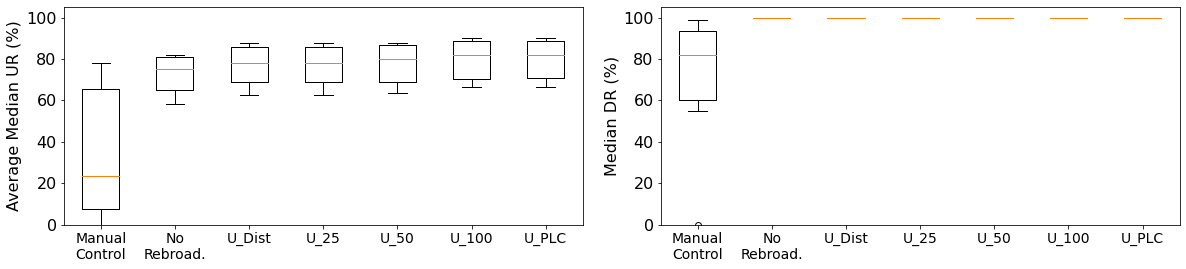

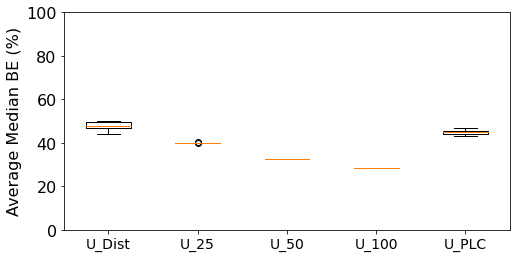

In [4]:
# fig, ax = plt.subplots(figsize=(14, 6))
# plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'small'})
# for i in range(len(CASES)):
#     plt.plot(["Manual Control\n(No Mitigation)", "Waypoint Control\n(No Rebroadcasting)", "Distance-Based", "PLCB", "Fixed Probability", "PLCB "], 
#              [manual_90[i], waypoint_90[i], dv_90[i], pm_90[i], fp_90[i], pm_gcs_90[i]], '-o')
# plt.legend(["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], fontsize=12, loc='upper left')
# plt.ylabel("Percentage (%)")
# # plt.xlabel('',fontsize=12)
# plt.ylim(0,100)
# plt.text(0.33, -0.2, "| ---------------------- Only UAV Rebroadcasting ---------------------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.87, -0.2, "   With GCS & UAV   \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)
# plt.text(0.33, -0.3, "| ---------------------- Waypoint Control With Packet Rebroadcasting ---------------------- |", transform=ax.transAxes, fontsize=14)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
# for i in range(len(CASES)):
#     ax1.plot(["Manual\nControl", "Waypoint\nControl\nOnly", "Distance-\nBased", "Fixed\nProbability", "PLCB+"], 
#              [manual_med_rel[i], waypoint_med_rel[i], dv_med_rel[i], fp_med_rel[i], pm_gcs_med_rel[i]], '-o')
ax1.boxplot([manual_med_rel, waypoint_med_rel, dv_med_rel, fp_25_med_rel, fp_50_med_rel, fp_100_med_rel, pm_med_rel], showmeans=False, 
            labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"])
ax1.set_ylabel("Average Median UR (%)")
ax1.set_ylim(0,105)
ax1.set_xticklabels(["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=14)
# plt.text(0.4, -0.2, "| -------------- Only UAV Rebroadcasting -------------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.84, -0.2, "   With GCS & UAV   \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)
# plt.text(0.4, -0.3, "| ------------------- Waypoint Control With Rebroadcasting ------------------- |", transform=ax.transAxes, fontsize=14)

# for i in range(len(CASES)):
#     ax2.plot(["Manual\nControl", "Waypoint\nControl\nOnly", "Distance-\nBased", "Fixed\nProbability", "PLCB+"], 
#              [manual_med_ul_rel[i], waypoint_med_ul_rel[i], dv_med_ul_rel[i], fp_med_ul_rel[i], pm_gcs_med_ul_rel[i]], '-o')
ax2.boxplot([manual_med_ul_rel, waypoint_med_ul_rel, dv_med_ul_rel, fp_25_med_ul_rel, fp_50_med_ul_rel, fp_100_med_ul_rel, pm_med_ul_rel], showmeans=False, 
            labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"])
ax2.set_ylabel("Median DR (%)")
ax2.set_ylim(0,105)
ax2.set_xticklabels(["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=14)
# plt.text(0.4, -0.2, "| -------------- Only UAV Rebroadcasting -------------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.84, -0.2, "   With GCS & UAV   \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)
# plt.text(0.4, -0.3, "| -------------- Waypoint Control With Packet Rebroadcasting -------------- |", transform=ax.transAxes, fontsize=14)
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(-0.35, 1.1, 1, 0.2), loc="lower right", fontsize=14, ncol=6) 
plt.subplots_adjust(wspace=0.15)

fig, ax = plt.subplots(figsize=(8, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
# for i in range(len(CASES)):
#     plt.plot(["Distance-Based", "Fixed Probability", "PLCB+"], 
#              [dv_med_uprr[i], fp_med_uprr[i], pm_gcs_med_uprr[i]], '-o')
plt.boxplot([dv_med_uprr, fp_25_med_uprr, fp_50_med_uprr, fp_100_med_uprr, pm_med_uprr], showmeans=False, 
            labels=["U_Dist", "U_25", "U_50", "U_100", "U_PLC"])
plt.ylabel("Average Median BE (%)")
plt.ylim(0,100)
plt.xticks(fontsize=14)
# plt.xlim([-0.15,4.15])
# plt.text(-0.02, -0.2, "| --------------------------- Only UAV Rebroadcasting --------------------------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.83, -0.2, "   With GCS & UAV   \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(0, 1.1, 1, 0.2), loc="lower center", fontsize=14, borderaxespad=0, ncol=6) 

In [12]:
# Print values for table
# Paste the cell output to NotePad, then copy paste to excel

# print("Percent > 90%")
# for i in range(len(CASES)):
#     print("{},{},{},{},{},{}".format(manual_90[i], waypoint_90[i], dv_90[i], fp_90[i], pm_90[i], pm_gcs_90[i]))

print("Median DL Rel")
for i in range(len(CASES)):
    print("{},{},{},{},{},{},{}".format(manual_med_rel[i], waypoint_med_rel[i], dv_med_rel[i], fp_25_med_rel[i], fp_50_med_rel[i], fp_100_med_rel[i], pm_med_rel[i]))

print("Median UL Rel")
for i in range(len(CASES)):
    print("{},{},{},{},{},{},{}".format(manual_med_ul_rel[i], waypoint_med_ul_rel[i], dv_med_ul_rel[i], fp_25_med_ul_rel[i], fp_50_med_ul_rel[i], fp_100_med_ul_rel[i], pm_med_ul_rel[i]))

print("Median UPRR")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_med_uprr[i], fp_25_med_uprr[i], fp_50_med_uprr[i], fp_100_med_uprr[i], pm_med_uprr[i]))

Median DL Rel
78.03565370598415,81.91699604743084,87.5,87.5,87.5,90.0,90.0
5.639824630426853,81.7471590909091,87.5,87.5,87.5,89.03508771929825,88.88888888888889
0.0,77.65151515151516,81.25,81.46306818181819,84.688995215311,87.2961956521739,87.5
75.58342562075413,72.72727272727273,75.0,75.0,75.0,76.44156346749226,76.47058823529412
34.46392011999279,62.58223684210526,66.66666666666666,66.66666666666666,66.66666666666666,68.50328947368422,68.70888157894737
12.83009658063768,58.062513847522496,62.5,62.5,63.63636363636363,66.66666666666666,66.66666666666666
Median UL Rel
75.41774903738094,100.0,100.0,100.0,100.0,100.0,100.0
55.04250420261797,100.0,100.0,100.0,100.0,100.0,100.0
0.0,100.0,100.0,100.0,100.0,100.0,100.0
98.72753297241984,100.0,100.0,100.0,100.0,100.0,100.0
94.96212805520182,100.0,100.0,100.0,100.0,100.0,100.0
88.44107350917612,100.0,100.0,100.0,100.0,100.0,100.0
Median UPRR
44.19741756351663,39.65155935155474,32.27651080794409,28.18928467365967,46.69783802333562
46.573212943151

#### For With GCS

In [ ]:
# Plot Median DL Reliability and Media UPRR

TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
dmax_df = pd.read_csv("/home/research-student/omnet-fanet/data-processing-scripts/manual_control_max_hdist/Dmax_RelTh999_Simulated_Reliability_v3_10e5.csv")
SWITCH_DETAILS = "/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/obj3_scenario_script_new/{}/Switch_Details.csv"
bitrate_2_usi_index = {6.5: 0, 13: 1, 19.5: 2, 26: 3, 39: 4, 52: 5, 58.5: 6, 65: 7}

pm_gcs_med_rel = []
fp_25_gcs_med_rel = []
fp_50_gcs_med_rel = []
fp_100_gcs_med_rel = []
dv_gcs_med_rel = []

pm_gcs_med_ul_rel = []
fp_25_gcs_med_ul_rel = []
fp_50_gcs_med_ul_rel = []
fp_100_gcs_med_ul_rel = []
dv_gcs_med_ul_rel = []

pm_gcs_med_uprr = []
fp_25_gcs_med_uprr = []
fp_50_gcs_med_uprr = []
fp_100_gcs_med_uprr = []
dv_gcs_med_uprr = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"

    """ Compile without filtering runs that switched too late (1 sec away from max time based on D_max) """
    # pm_gcs_df = compile_results(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_25_gcs_df = compile_results(FP_25_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_50_gcs_df = compile_results(FP_50_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_100_gcs_df = compile_results(FP_100_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # dv_gcs_df = compile_results(DV_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    '''For Custom Run Num Range'''
    pm_gcs_df = compile_results_range(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_25_gcs_df = compile_results_range(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_50_gcs_df = compile_results_range(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_100_gcs_df = compile_results_range(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    dv_gcs_df = compile_results_range(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)

    """ Compile, filtering runs that switched too late (1 sec away from max time based on D_max) """
    # switch_details_df = pd.read_csv(SWITCH_DETAILS.format(case[0:-10]))
    # switch_time_df = switch_details_df[["GCS_Switch_Time", "GW_Switch_Time", "UAV_0_Switch_Time", "UAV_2_Switch_Time", "UAV_3_Switch_Time", "UAV_4_Switch_Time",
    #                                     "UAV_5_Switch_Time", "UAV_6_Switch_Time", "UAV_7_Switch_Time"]]
    # switch_time_df_notna = switch_details_df.loc[~switch_time_df.isnull().all(axis=1)]
    # max_time = []
    # for row in switch_time_df_notna.itertuples():
    #     usi = row.USI
    #     mcs_index = bitrate_2_usi_index[row.Bit_Rate]
    #     height = row.Height
    #     speed = row.UAV_Speed
    #     D_max = dmax_df.loc[(dmax_df["MCS_Index"]==mcs_index) & (dmax_df["USI"]==usi) & (dmax_df["Height"]==height)]["D_max"].values[0]
    #     max_time.append(D_max/speed)
    # switch_time_df_notna["Max_Time"] = max_time
    # switch_time_df_notna["Min_Switch_Time"] = switch_time_df_notna[["GCS_Switch_Time", "GW_Switch_Time", "UAV_0_Switch_Time", "UAV_2_Switch_Time", "UAV_3_Switch_Time", "UAV_4_Switch_Time",
    #                                                 "UAV_5_Switch_Time", "UAV_6_Switch_Time", "UAV_7_Switch_Time"]].min(axis=1)
    # filter_df = switch_time_df_notna.loc[switch_time_df_notna["Min_Switch_Time"] > (switch_time_df_notna["Max_Time"]-1)]
    # manual_df = compile_results_filtered(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df, "Simulation_Results.csv")
    # waypoint_df = compile_results_filtered(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # fp_df = compile_results_filtered(FP_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # dv_df = compile_results_filtered(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # pm_df = compile_results_filtered(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # pm_gcs_df = compile_results_filtered(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        pm_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_25_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_50_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_100_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        dv_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    runs_nan = (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy()) | \
                (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_100_gcs_df.isnull().any(axis=1).to_numpy()) 
    pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    '''Get Median DL Reliability'''
    # pm_gcs_dl_rel = np.concatenate((pm_gcs_df_fil["Reliability_UAV_0"].values*100, pm_gcs_df_fil["Reliability_UAV_1"].values*100, pm_gcs_df_fil["Reliability_UAV_2"].values*100, pm_gcs_df_fil["Reliability_UAV_3"].values*100,
    #                             pm_gcs_df_fil["Reliability_UAV_4"].values*100, pm_gcs_df_fil["Reliability_UAV_5"].values*100, pm_gcs_df_fil["Reliability_UAV_6"].values*100, pm_gcs_df_fil["Reliability_UAV_7"].values*100))
    pm_gcs_dl_rel = np.mean((pm_gcs_df_fil["Reliability_UAV_0"].median()*100, pm_gcs_df_fil["Reliability_UAV_1"].median()*100, pm_gcs_df_fil["Reliability_UAV_2"].median()*100, pm_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                pm_gcs_df_fil["Reliability_UAV_4"].median()*100, pm_gcs_df_fil["Reliability_UAV_5"].median()*100, pm_gcs_df_fil["Reliability_UAV_6"].median()*100, pm_gcs_df_fil["Reliability_UAV_7"].median()*100))
    fp_25_gcs_dl_rel = np.mean((fp_25_gcs_df_fil["Reliability_UAV_0"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_1"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_2"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                fp_25_gcs_df_fil["Reliability_UAV_4"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_5"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_6"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_7"].median()*100))
    fp_50_gcs_dl_rel = np.mean((fp_50_gcs_df_fil["Reliability_UAV_0"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_1"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_2"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                fp_50_gcs_df_fil["Reliability_UAV_4"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_5"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_6"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_7"].median()*100))
    fp_100_gcs_dl_rel = np.mean((fp_100_gcs_df_fil["Reliability_UAV_0"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_1"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_2"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                fp_100_gcs_df_fil["Reliability_UAV_4"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_5"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_6"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_7"].median()*100))
    dv_gcs_dl_rel = np.mean((dv_gcs_df_fil["Reliability_UAV_0"].median()*100, dv_gcs_df_fil["Reliability_UAV_1"].median()*100, dv_gcs_df_fil["Reliability_UAV_2"].median()*100, dv_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                dv_gcs_df_fil["Reliability_UAV_4"].median()*100, dv_gcs_df_fil["Reliability_UAV_5"].median()*100, dv_gcs_df_fil["Reliability_UAV_6"].median()*100, dv_gcs_df_fil["Reliability_UAV_7"].median()*100))
    
    pm_gcs_med_rel.append(pm_gcs_dl_rel)
    fp_25_gcs_med_rel.append(fp_25_gcs_dl_rel)
    fp_50_gcs_med_rel.append(fp_50_gcs_dl_rel)
    fp_100_gcs_med_rel.append(fp_100_gcs_dl_rel)
    dv_gcs_med_rel.append(dv_gcs_dl_rel)

    '''Get Median UL Reliability'''
    pm_gcs_med_ul_rel.append(pm_gcs_df_fil["Total_Reliability_UL"].median() * 100)
    fp_25_gcs_med_ul_rel.append(fp_25_gcs_df_fil["Total_Reliability_UL"].median() * 100)
    fp_50_gcs_med_ul_rel.append(fp_50_gcs_df_fil["Total_Reliability_UL"].median() * 100)
    fp_100_gcs_med_ul_rel.append(fp_100_gcs_df_fil["Total_Reliability_UL"].median() * 100)
    dv_gcs_med_ul_rel.append(dv_gcs_df_fil["Total_Reliability_UL"].median() * 100)

    '''Get Median UPRR'''
    # pm_gcs_dl_uprr = np.concatenate((pm_gcs_df_fil["UPRR_UAV_0"].values*100, pm_gcs_df_fil["UPRR_UAV_1"].values*100, pm_gcs_df_fil["UPRR_UAV_2"].values*100, pm_gcs_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_gcs_df_fil["UPRR_UAV_4"].values*100, pm_gcs_df_fil["UPRR_UAV_5"].values*100, pm_gcs_df_fil["UPRR_UAV_6"].values*100, pm_gcs_df_fil["UPRR_UAV_7"].values*100))
    pm_gcs_dl_uprr = np.mean((pm_gcs_df_fil["UPRR_UAV_0"].median()*100, pm_gcs_df_fil["UPRR_UAV_1"].median()*100, pm_gcs_df_fil["UPRR_UAV_2"].median()*100, pm_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                pm_gcs_df_fil["UPRR_UAV_4"].median()*100, pm_gcs_df_fil["UPRR_UAV_5"].median()*100, pm_gcs_df_fil["UPRR_UAV_6"].median()*100, pm_gcs_df_fil["UPRR_UAV_7"].median()*100))
    fp_25_gcs_dl_uprr = np.mean((fp_25_gcs_df_fil["UPRR_UAV_0"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_1"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_2"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                fp_25_gcs_df_fil["UPRR_UAV_4"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_5"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_6"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_7"].median()*100))
    fp_50_gcs_dl_uprr = np.mean((fp_50_gcs_df_fil["UPRR_UAV_0"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_1"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_2"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                fp_50_gcs_df_fil["UPRR_UAV_4"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_5"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_6"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_7"].median()*100))
    fp_100_gcs_dl_uprr = np.mean((fp_100_gcs_df_fil["UPRR_UAV_0"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_1"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_2"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                fp_100_gcs_df_fil["UPRR_UAV_4"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_5"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_6"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_7"].median()*100))
    dv_gcs_dl_uprr = np.mean((dv_gcs_df_fil["UPRR_UAV_0"].median()*100, dv_gcs_df_fil["UPRR_UAV_1"].median()*100, dv_gcs_df_fil["UPRR_UAV_2"].median()*100, dv_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                dv_gcs_df_fil["UPRR_UAV_4"].median()*100, dv_gcs_df_fil["UPRR_UAV_5"].median()*100, dv_gcs_df_fil["UPRR_UAV_6"].median()*100, dv_gcs_df_fil["UPRR_UAV_7"].median()*100))
    pm_gcs_med_uprr.append(pm_gcs_dl_uprr)
    fp_25_gcs_med_uprr.append(fp_25_gcs_dl_uprr)
    fp_50_gcs_med_uprr.append(fp_50_gcs_dl_uprr)
    fp_100_gcs_med_uprr.append(fp_100_gcs_dl_uprr)
    dv_gcs_med_uprr.append(dv_gcs_dl_uprr)



(array([1, 2, 3, 4, 5]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

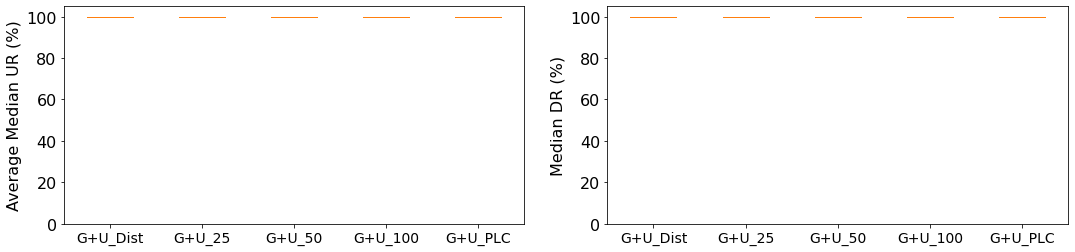

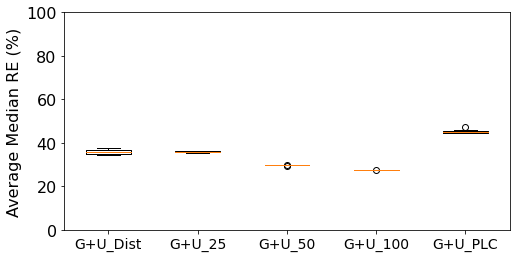

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
ax1.boxplot([dv_gcs_med_rel, fp_25_gcs_med_rel, fp_50_gcs_med_rel, fp_100_gcs_med_rel, pm_gcs_med_rel], showmeans=False, 
            labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])
ax1.set_ylabel("Average Median UR (%)")
ax1.set_ylim(0,105)
ax1.set_xticklabels(["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=14)

ax2.boxplot([dv_gcs_med_ul_rel, fp_25_gcs_med_ul_rel, fp_50_gcs_med_ul_rel, fp_100_gcs_med_ul_rel, pm_gcs_med_ul_rel], showmeans=False, 
            labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])
ax2.set_ylabel("Median DR (%)")
ax2.set_ylim(0,105)
ax2.set_xticklabels(["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=14)
plt.subplots_adjust(wspace=0.18)

fig, ax = plt.subplots(figsize=(8, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
plt.boxplot([dv_gcs_med_uprr, fp_25_gcs_med_uprr, fp_50_gcs_med_uprr, fp_100_gcs_med_uprr, pm_gcs_med_uprr], whis=[0, 100], showmeans=False, 
            labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])
plt.ylabel("Average Median RE (%)")
plt.ylim(0,100)
plt.xticks(fontsize=14) 

In [8]:
# Print values for table
# Paste the cell output to NotePad, then copy paste to excel
print("Median DL Rel")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_gcs_med_rel[i], fp_25_gcs_med_rel[i], fp_50_gcs_med_rel[i], fp_100_gcs_med_rel[i], pm_gcs_med_rel[i]))

print("Median UL Rel")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_gcs_med_ul_rel[i], fp_25_gcs_med_ul_rel[i], fp_50_gcs_med_ul_rel[i], fp_100_gcs_med_ul_rel[i], pm_gcs_med_ul_rel[i]))

print("Median UPRR")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_gcs_med_uprr[i], fp_25_gcs_med_uprr[i], fp_50_gcs_med_uprr[i], fp_100_gcs_med_uprr[i], pm_gcs_med_uprr[i]))

Median DL Rel
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
Median UL Rel
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
Median UPRR
34.22960158596552,35.483870967741936,29.418329831932766,27.515304847576214,47.06932773109243
34.782608695652165,35.537634408602145,29.67997294169169,27.500000000000004,45.00686813186813
35.41795748418302,35.537634408602145,29.707294109468023,27.329816017316013,44.37293217535153
35.96436403508772,35.98341557017544,29.691699171998085,27.50452898550725,45.65421293682162
36.75532735780337,36.36363636363636,29.7448567970956,27.55392438009183,44.80029168774847
37.33609623033647,36.385489510489506,29.821133956740912,27.528223094828423,44.44444444444444


### Plot Rebroadcast Efficiency (Calculated from all runs of each combination)

In [ ]:
# NOTE: For the 100 runs result, result obtained from ANY run num range, as long as its from the "valid" runs

FP_25_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
TH_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
RUN_NUM = 500 # NOTE: Change the no. of runs used here
SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Mean_Rebroadcast_Efficienct_{}_runs.csv".format(RUN_NUM)

# To store results
df_list = []
scenario_list = []
fp_25_result = []
fp_50_result = []
fp_100_result = []
dv_result = []
pm_result = []
fp_25_gcs_result = []
fp_50_gcs_result = []
fp_100_gcs_result = []
dv_gcs_result = []
pm_gcs_result = []

for case in tqdm(CASES):
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    
    scenarios = sorted(glob.glob(os.path.join(FP_25_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_25_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_25_df_fil = fp_25_df.loc[~(fp_25_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_25_df_fil) > 0:
            fp_25_df_fil = fp_25_df_fil.head(RUN_NUM)
            fp_25_result.append(np.nanmean((fp_25_df_fil["UPRR_UAV_0"].mean()*100, fp_25_df_fil["UPRR_UAV_1"].mean()*100, fp_25_df_fil["UPRR_UAV_2"].mean()*100, fp_25_df_fil["UPRR_UAV_3"].mean()*100,
                                        fp_25_df_fil["UPRR_UAV_4"].mean()*100, fp_25_df_fil["UPRR_UAV_5"].mean()*100, fp_25_df_fil["UPRR_UAV_6"].mean()*100, fp_25_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_25_result.append(np.nan)
        scenario_list.append(scenario)

    scenarios = sorted(glob.glob(os.path.join(FP_50_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_50_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_50_df_fil = fp_50_df.loc[~(fp_50_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_50_df_fil) > 0:
            fp_50_df_fil = fp_50_df_fil.head(RUN_NUM)
            fp_50_result.append(np.nanmean((fp_50_df_fil["UPRR_UAV_0"].mean()*100, fp_50_df_fil["UPRR_UAV_1"].mean()*100, fp_50_df_fil["UPRR_UAV_2"].mean()*100, fp_50_df_fil["UPRR_UAV_3"].mean()*100,
                                        fp_50_df_fil["UPRR_UAV_4"].mean()*100, fp_50_df_fil["UPRR_UAV_5"].mean()*100, fp_50_df_fil["UPRR_UAV_6"].mean()*100, fp_50_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_50_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(FP_100_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_100_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_100_df_fil = fp_100_df.loc[~(fp_100_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_100_df_fil) > 0:
            fp_100_df_fil = fp_100_df_fil.head(RUN_NUM)
            fp_100_result.append(np.nanmean((fp_100_df_fil["UPRR_UAV_0"].mean()*100, fp_100_df_fil["UPRR_UAV_1"].mean()*100, fp_100_df_fil["UPRR_UAV_2"].mean()*100, fp_100_df_fil["UPRR_UAV_3"].mean()*100,
                                        fp_100_df_fil["UPRR_UAV_4"].mean()*100, fp_100_df_fil["UPRR_UAV_5"].mean()*100, fp_100_df_fil["UPRR_UAV_6"].mean()*100, fp_100_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_100_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(TH_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        pm_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        pm_df_fil = pm_df.loc[~(pm_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(pm_df_fil) > 0:
            pm_df_fil = pm_df_fil.head(RUN_NUM)
            pm_result.append(np.nanmean((pm_df_fil["UPRR_UAV_0"].mean()*100, pm_df_fil["UPRR_UAV_1"].mean()*100, pm_df_fil["UPRR_UAV_2"].mean()*100, pm_df_fil["UPRR_UAV_3"].mean()*100,
                                    pm_df_fil["UPRR_UAV_4"].mean()*100, pm_df_fil["UPRR_UAV_5"].mean()*100, pm_df_fil["UPRR_UAV_6"].mean()*100, pm_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            pm_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(DV_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        dv_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        dv_df_fil = dv_df.loc[~(dv_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(dv_df_fil) > 0:
            dv_df_fil = dv_df_fil.head(RUN_NUM)
            dv_result.append(np.nanmean((dv_df_fil["UPRR_UAV_0"].mean()*100, dv_df_fil["UPRR_UAV_1"].mean()*100, dv_df_fil["UPRR_UAV_2"].mean()*100, dv_df_fil["UPRR_UAV_3"].mean()*100,
                                    dv_df_fil["UPRR_UAV_4"].mean()*100, dv_df_fil["UPRR_UAV_5"].mean()*100, dv_df_fil["UPRR_UAV_6"].mean()*100, dv_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            dv_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(FP_25_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_25_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(fp_25_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_25_gcs_df_fil) > 0:
            fp_25_gcs_df_fil = fp_25_gcs_df_fil.head(RUN_NUM)
            fp_25_gcs_result.append(np.nanmean((fp_25_gcs_df_fil["UPRR_UAV_0"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_1"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_2"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    fp_25_gcs_df_fil["UPRR_UAV_4"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_5"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_6"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_25_gcs_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(FP_50_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_50_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(fp_50_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_50_gcs_df_fil) > 0:
            fp_50_gcs_df_fil = fp_50_gcs_df_fil.head(RUN_NUM)
            fp_50_gcs_result.append(np.nanmean((fp_50_gcs_df_fil["UPRR_UAV_0"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_1"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_2"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    fp_50_gcs_df_fil["UPRR_UAV_4"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_5"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_6"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_50_gcs_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(FP_100_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_100_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(fp_100_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_100_gcs_df_fil) > 0:
            fp_100_gcs_df_fil = fp_100_gcs_df_fil.head(RUN_NUM)
            fp_100_gcs_result.append(np.nanmean((fp_100_gcs_df_fil["UPRR_UAV_0"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_1"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_2"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    fp_100_gcs_df_fil["UPRR_UAV_4"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_5"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_6"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_100_gcs_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(DV_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        pm_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        pm_gcs_df_fil = pm_gcs_df.loc[~(pm_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(pm_gcs_df_fil) > 0:
            pm_gcs_df_fil = pm_gcs_df_fil.head(RUN_NUM)
            pm_gcs_result.append(np.nanmean((pm_gcs_df_fil["UPRR_UAV_0"].mean()*100, pm_gcs_df_fil["UPRR_UAV_1"].mean()*100, pm_gcs_df_fil["UPRR_UAV_2"].mean()*100, pm_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    pm_gcs_df_fil["UPRR_UAV_4"].mean()*100, pm_gcs_df_fil["UPRR_UAV_5"].mean()*100, pm_gcs_df_fil["UPRR_UAV_6"].mean()*100, pm_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            pm_gcs_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(TH_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        dv_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        dv_gcs_df_fil = dv_gcs_df.loc[~(dv_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(dv_gcs_df_fil) > 0:
            dv_gcs_df_fil = dv_gcs_df_fil.head(RUN_NUM)
            dv_gcs_result.append(np.nanmean((dv_gcs_df_fil["UPRR_UAV_0"].mean()*100, dv_gcs_df_fil["UPRR_UAV_1"].mean()*100, dv_gcs_df_fil["UPRR_UAV_2"].mean()*100, dv_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    dv_gcs_df_fil["UPRR_UAV_4"].mean()*100, dv_gcs_df_fil["UPRR_UAV_5"].mean()*100, dv_gcs_df_fil["UPRR_UAV_6"].mean()*100, dv_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            dv_gcs_result.append(np.nan)  
    
    case_result_df = pd.DataFrame({"Interference_Scenario": [case]*len(scenario_list),
                                   "Scenario": scenario_list,
                                   "FP_25": fp_25_result,
                                   "FP_50": fp_50_result,
                                   "FP_100": fp_100_result,
                                   "DV": dv_result,
                                   "PM": pm_result,
                                   "FP_25_GCS": fp_25_gcs_result,
                                   "FP_50_GCS": fp_50_gcs_result,
                                   "FP_100_GCS": fp_100_gcs_result,
                                   "DV_GCS": dv_gcs_result,
                                   "PM_GCS": pm_gcs_result})
    df_list.append(case_result_df)
    
df_result = pd.concat(df_list)
df_result.to_csv(SAVEPATH)

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:07<00:00,  1.20s/it]


In [4]:
# With the 100 runs result obtained from range of runs spanning 100

FP_25_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
TH_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
START_RUN_NUM = 400
END_RUN_NUM = 499
SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Mean_Rebroadcast_Efficienct_{}-{}_runs.csv".format(START_RUN_NUM, END_RUN_NUM)


# To store results
df_list = []
scenario_list = []
fp_25_result = []
fp_50_result = []
fp_100_result = []
dv_result = []
pm_result = []
fp_25_gcs_result = []
fp_50_gcs_result = []
fp_100_gcs_result = []
dv_gcs_result = []
pm_gcs_result = []

for case in tqdm(CASES):
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    
    scenarios = sorted(glob.glob(os.path.join(FP_25_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_25_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_25_df = fp_25_df.loc[(fp_25_df["Run"]>=START_RUN_NUM) & (fp_25_df["Run"]<=END_RUN_NUM)]
        fp_25_df_fil = fp_25_df.loc[~(fp_25_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_25_df_fil) > 0:
            fp_25_result.append(np.nanmean((fp_25_df_fil["UPRR_UAV_0"].mean()*100, fp_25_df_fil["UPRR_UAV_1"].mean()*100, fp_25_df_fil["UPRR_UAV_2"].mean()*100, fp_25_df_fil["UPRR_UAV_3"].mean()*100,
                                        fp_25_df_fil["UPRR_UAV_4"].mean()*100, fp_25_df_fil["UPRR_UAV_5"].mean()*100, fp_25_df_fil["UPRR_UAV_6"].mean()*100, fp_25_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_25_result.append(np.nan)
        scenario_list.append(scenario)

    scenarios = sorted(glob.glob(os.path.join(FP_50_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_50_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_50_df = fp_50_df.loc[(fp_50_df["Run"]>=START_RUN_NUM) & (fp_50_df["Run"]<=END_RUN_NUM)]
        fp_50_df_fil = fp_50_df.loc[~(fp_50_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_50_df_fil) > 0:
            fp_50_result.append(np.nanmean((fp_50_df_fil["UPRR_UAV_0"].mean()*100, fp_50_df_fil["UPRR_UAV_1"].mean()*100, fp_50_df_fil["UPRR_UAV_2"].mean()*100, fp_50_df_fil["UPRR_UAV_3"].mean()*100,
                                        fp_50_df_fil["UPRR_UAV_4"].mean()*100, fp_50_df_fil["UPRR_UAV_5"].mean()*100, fp_50_df_fil["UPRR_UAV_6"].mean()*100, fp_50_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_50_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(FP_100_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_100_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_100_df = fp_100_df.loc[(fp_100_df["Run"]>=START_RUN_NUM) & (fp_100_df["Run"]<=END_RUN_NUM)]
        fp_100_df_fil = fp_100_df.loc[~(fp_100_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_100_df_fil) > 0:
            fp_100_result.append(np.nanmean((fp_100_df_fil["UPRR_UAV_0"].mean()*100, fp_100_df_fil["UPRR_UAV_1"].mean()*100, fp_100_df_fil["UPRR_UAV_2"].mean()*100, fp_100_df_fil["UPRR_UAV_3"].mean()*100,
                                        fp_100_df_fil["UPRR_UAV_4"].mean()*100, fp_100_df_fil["UPRR_UAV_5"].mean()*100, fp_100_df_fil["UPRR_UAV_6"].mean()*100, fp_100_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_100_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(TH_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        pm_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        pm_df = pm_df.loc[(pm_df["Run"]>=START_RUN_NUM) & (pm_df["Run"]<=END_RUN_NUM)]
        pm_df_fil = pm_df.loc[~(pm_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(pm_df_fil) > 0:
            pm_result.append(np.nanmean((pm_df_fil["UPRR_UAV_0"].mean()*100, pm_df_fil["UPRR_UAV_1"].mean()*100, pm_df_fil["UPRR_UAV_2"].mean()*100, pm_df_fil["UPRR_UAV_3"].mean()*100,
                                    pm_df_fil["UPRR_UAV_4"].mean()*100, pm_df_fil["UPRR_UAV_5"].mean()*100, pm_df_fil["UPRR_UAV_6"].mean()*100, pm_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            pm_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(DV_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        dv_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        dv_df = dv_df.loc[(dv_df["Run"]>=START_RUN_NUM) & (dv_df["Run"]<=END_RUN_NUM)]
        dv_df_fil = dv_df.loc[~(dv_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(dv_df_fil) > 0:
            dv_result.append(np.nanmean((dv_df_fil["UPRR_UAV_0"].mean()*100, dv_df_fil["UPRR_UAV_1"].mean()*100, dv_df_fil["UPRR_UAV_2"].mean()*100, dv_df_fil["UPRR_UAV_3"].mean()*100,
                                    dv_df_fil["UPRR_UAV_4"].mean()*100, dv_df_fil["UPRR_UAV_5"].mean()*100, dv_df_fil["UPRR_UAV_6"].mean()*100, dv_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            dv_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(FP_25_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_25_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_25_gcs_df = fp_25_gcs_df.loc[(fp_25_gcs_df["Run"]>=START_RUN_NUM) & (fp_25_gcs_df["Run"]<=END_RUN_NUM)]
        fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(fp_25_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_25_gcs_df_fil) > 0:
            fp_25_gcs_result.append(np.nanmean((fp_25_gcs_df_fil["UPRR_UAV_0"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_1"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_2"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    fp_25_gcs_df_fil["UPRR_UAV_4"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_5"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_6"].mean()*100, fp_25_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_25_gcs_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(FP_50_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_50_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_50_gcs_df = fp_50_gcs_df.loc[(fp_50_gcs_df["Run"]>=START_RUN_NUM) & (fp_50_gcs_df["Run"]<=END_RUN_NUM)]
        fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(fp_50_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_50_gcs_df_fil) > 0:
            fp_50_gcs_result.append(np.nanmean((fp_50_gcs_df_fil["UPRR_UAV_0"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_1"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_2"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    fp_50_gcs_df_fil["UPRR_UAV_4"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_5"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_6"].mean()*100, fp_50_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_50_gcs_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(FP_100_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        fp_100_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        fp_100_gcs_df = fp_100_gcs_df.loc[(fp_100_gcs_df["Run"]>=START_RUN_NUM) & (fp_100_gcs_df["Run"]<=END_RUN_NUM)]
        fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(fp_100_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(fp_100_gcs_df_fil) > 0:
            fp_100_gcs_result.append(np.nanmean((fp_100_gcs_df_fil["UPRR_UAV_0"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_1"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_2"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    fp_100_gcs_df_fil["UPRR_UAV_4"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_5"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_6"].mean()*100, fp_100_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            fp_100_gcs_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(DV_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        pm_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        pm_gcs_df = pm_gcs_df.loc[(pm_gcs_df["Run"]>=START_RUN_NUM) & (pm_gcs_df["Run"]<=END_RUN_NUM)]
        pm_gcs_df_fil = pm_gcs_df.loc[~(pm_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(pm_gcs_df_fil) > 0:
            pm_gcs_result.append(np.nanmean((pm_gcs_df_fil["UPRR_UAV_0"].mean()*100, pm_gcs_df_fil["UPRR_UAV_1"].mean()*100, pm_gcs_df_fil["UPRR_UAV_2"].mean()*100, pm_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    pm_gcs_df_fil["UPRR_UAV_4"].mean()*100, pm_gcs_df_fil["UPRR_UAV_5"].mean()*100, pm_gcs_df_fil["UPRR_UAV_6"].mean()*100, pm_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            pm_gcs_result.append(np.nan)

    scenarios = sorted(glob.glob(os.path.join(TH_GCS_PATH.format(intf_type), case, "*")))
    for scenario in scenarios:
        dv_gcs_df = pd.read_csv(os.path.join(scenario, "Broadcast_Metrics.csv"))
        dv_gcs_df = dv_gcs_df.loc[(dv_gcs_df["Run"]>=START_RUN_NUM) & (dv_gcs_df["Run"]<=END_RUN_NUM)]
        dv_gcs_df_fil = dv_gcs_df.loc[~(dv_gcs_df.isnull().any(axis=1).to_numpy())]  # Filter out runs where there are NaN results (invalid)
        if len(dv_gcs_df_fil) > 0:
            dv_gcs_result.append(np.nanmean((dv_gcs_df_fil["UPRR_UAV_0"].mean()*100, dv_gcs_df_fil["UPRR_UAV_1"].mean()*100, dv_gcs_df_fil["UPRR_UAV_2"].mean()*100, dv_gcs_df_fil["UPRR_UAV_3"].mean()*100,
                                    dv_gcs_df_fil["UPRR_UAV_4"].mean()*100, dv_gcs_df_fil["UPRR_UAV_5"].mean()*100, dv_gcs_df_fil["UPRR_UAV_6"].mean()*100, dv_gcs_df_fil["UPRR_UAV_7"].mean()*100)))
        else:
            dv_gcs_result.append(np.nan)  
    
    case_result_df = pd.DataFrame({"Interference_Scenario": [case]*len(scenario_list),
                                   "Scenario": scenario_list,
                                   "FP_25": fp_25_result,
                                   "FP_50": fp_50_result,
                                   "FP_100": fp_100_result,
                                   "DV": dv_result,
                                   "PM": pm_result,
                                   "FP_25_GCS": fp_25_gcs_result,
                                   "FP_50_GCS": fp_50_gcs_result,
                                   "FP_100_GCS": fp_100_gcs_result,
                                   "DV_GCS": dv_gcs_result,
                                   "PM_GCS": pm_gcs_result})
    df_list.append(case_result_df)
    
df_result = pd.concat(df_list)
df_result.to_csv(SAVEPATH)

100%|██████████| 6/6 [00:14<00:00,  2.39s/it]


(-1.0, 105.0)

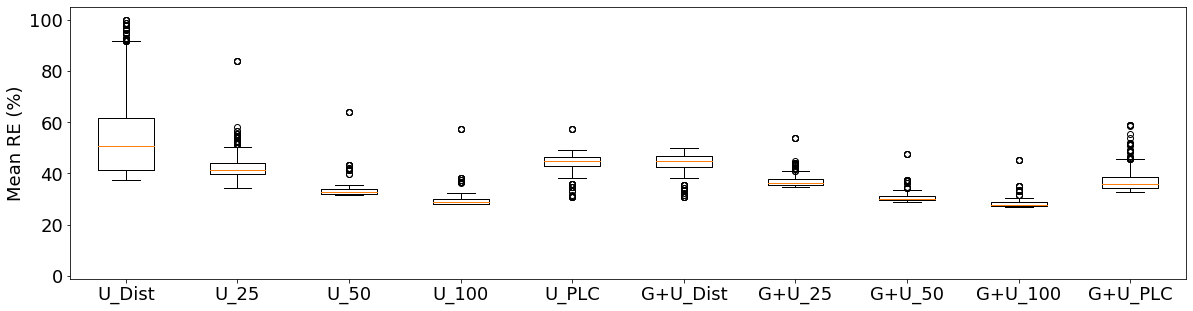

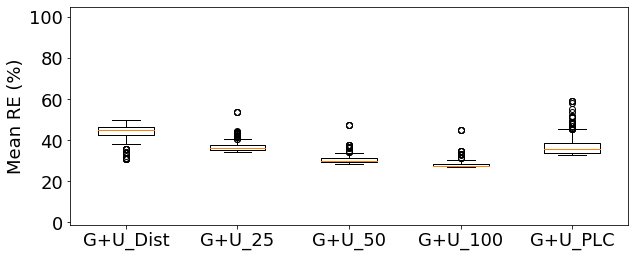

In [35]:
df_result = pd.read_csv("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Mean_Rebroadcast_Efficienct_400-499_runs.csv")

plt.rcParams.update({'font.size': 18, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
# With one box plots for results of all schemes
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
ax.boxplot([df_result["DV"].dropna().values, df_result["FP_25"].dropna().values,
            df_result["FP_50"].dropna().values, df_result["FP_100"].dropna().values, df_result["PM"].dropna().values, df_result["DV_GCS"].dropna().values,
            df_result["FP_25_GCS"].dropna().values, df_result["FP_50_GCS"].dropna().values, df_result["FP_100_GCS"].dropna().values, df_result["PM_GCS"].dropna().values],
            showmeans=False, labels=["U_Dist", "U_25", "U_50", "U_100", "U_PLC", "G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"],)

ax.set_ylabel("Mean RE (%)")
ax.set_ylim(-1,105)

# With one box plots for results of UAV+GCS rebroadcasting schemes
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.boxplot([df_result["DV_GCS"].dropna().values,df_result["FP_25_GCS"].dropna().values, df_result["FP_50_GCS"].dropna().values, df_result["FP_100_GCS"].dropna().values, df_result["PM_GCS"].dropna().values],
            showmeans=False, labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"],)

ax1.set_ylabel("Mean RE (%)")
ax1.set_ylim(-1,105)

### Plot Consecutive Packet Failure Results (Calculated from all runs of each combination)

#### For Type-2/Type-3 Loss, All Schemes

In [3]:
# With the 100 runs result obtained from ANY run num range, as long as its from the "valid" runs
SAVEPATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/results_new_Mar25/Prob_NPRL_NC_{}_500_runs.csv"
# Plot Percentage of Sim Runs with Consecutive Packet Failures
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_{}_Interference_new"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
NUM_RUN = 500
MAX_RUN_NUM = 499 # Run num starts at 0
# START_RUN_NUM = 0
# END_RUN_NUM = 499
N_SECS = 2
usi_list = ["10", "20", "66.7", "100"]

# To store the percentage of sim runs with no cons packet failures
df_list = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    # manual_df = compile_results_range(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results_range(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_gcs_df = compile_results_range(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_gcs_df = compile_results_range(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_gcs_df = compile_results_range(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_gcs_df = compile_results_range(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_gcs_df = compile_results_range(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    # runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
    #         (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy()) | \
    #         (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | \
    #         (fp_100_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy())
    # manual_df_fil = manual_df.loc[~(runs_nan)]
    # waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    # fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    # fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    # fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    # dv_df_fil = dv_df.loc[~(runs_nan)]
    # pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    # fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    # fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    # fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    # dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    manual_df_fil = manual_df.loc[~(manual_df.isnull().any(axis=1).to_numpy())]
    waypoint_df_fil = waypoint_df.loc[~(waypoint_df.isnull().any(axis=1).to_numpy())]
    fp_25_df_fil = fp_25_df.loc[~(fp_25_df.isnull().any(axis=1).to_numpy())]
    fp_50_df_fil = fp_50_df.loc[~(fp_50_df.isnull().any(axis=1).to_numpy())]
    fp_100_df_fil = fp_100_df.loc[~(fp_100_df.isnull().any(axis=1).to_numpy())]
    dv_df_fil = dv_df.loc[~(dv_df.isnull().any(axis=1).to_numpy())]
    pm_df_fil = pm_df.loc[~(pm_df.isnull().any(axis=1).to_numpy())]
    pm_gcs_df_fil = pm_gcs_df.loc[~(pm_gcs_df.isnull().any(axis=1).to_numpy())]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(fp_25_gcs_df.isnull().any(axis=1).to_numpy())]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(fp_50_gcs_df.isnull().any(axis=1).to_numpy())]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(fp_100_gcs_df.isnull().any(axis=1).to_numpy())]
    dv_gcs_df_fil = dv_gcs_df.loc[~(dv_gcs_df.isnull().any(axis=1).to_numpy())]

    '''For each scheme, for each Scenario, Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    manual_result_group = [] # These are to store results per USI for the current scenario
    waypoint_result_group = []
    fp_25_result_group = []
    fp_50_result_group = []
    fp_100_result_group = []
    dv_result_group = []
    pm_result_group = []
    pm_gcs_result_group = []
    fp_25_gcs_result_group = []
    fp_50_gcs_result_group = []
    fp_100_gcs_result_group = []
    dv_gcs_result_group = []

    group_list = []
    '''Group by Scenario'''
    manual_groups = manual_df_fil.groupby(['Scenario'])
    waypoint_groups = waypoint_df_fil.groupby(['Scenario'])
    fp_25_groups = fp_25_df_fil.groupby(['Scenario'])
    fp_50_groups = fp_50_df_fil.groupby(['Scenario'])
    fp_100_groups = fp_100_df_fil.groupby(['Scenario'])
    dv_groups = dv_df_fil.groupby(['Scenario'])
    pm_groups = pm_df_fil.groupby(['Scenario'])
    pm_gcs_groups = pm_gcs_df_fil.groupby(['Scenario'])
    fp_25_gcs_groups = fp_25_gcs_df_fil.groupby(['Scenario'])
    fp_50_gcs_groups = fp_50_gcs_df_fil.groupby(['Scenario'])
    fp_100_gcs_groups = fp_100_gcs_df_fil.groupby(['Scenario'])
    dv_gcs_groups = dv_gcs_df_fil.groupby(['Scenario'])

    # NOTE: Some scenario may not be feasible for mitigation schemes for the current N_SECS, since sim time not enough for N_SECS cons. packet loss to happen
    # Handle uncommon cases for manual_groups
    for group in set(manual_groups.groups.keys() - waypoint_groups.groups.keys()):
        group_list.append(group)
        
        manual_group_df = manual_groups.get_group(group)
        manual_group_df = manual_group_df.tail(NUM_RUN)
        manual_result_group.append(len(manual_group_df.loc[(manual_group_df["UAV_0_Cons_Fail"] == 0) &
                                (manual_group_df["UAV_1_Cons_Fail"] == 0) & (manual_group_df["UAV_2_Cons_Fail"] == 0) &
                                (manual_group_df["UAV_3_Cons_Fail"] == 0) & (manual_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (manual_group_df["UAV_5_Cons_Fail"] == 0) & (manual_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (manual_group_df["UAV_7_Cons_Fail"] == 0)])/len(manual_group_df) * 100)
        waypoint_result_group.append(np.nan)
        fp_25_result_group.append(np.nan)
        fp_50_result_group.append(np.nan)
        fp_100_result_group.append(np.nan)
        dv_result_group.append(np.nan)
        pm_result_group.append(np.nan)
        pm_gcs_result_group.append(np.nan)
        fp_25_gcs_result_group.append(np.nan)
        fp_50_gcs_result_group.append(np.nan)
        fp_100_gcs_result_group.append(np.nan)
        dv_gcs_result_group.append(np.nan)

    for group in set(waypoint_groups.groups.keys()):
        group_list.append(group)

        manual_group_df = manual_groups.get_group(group)
        manual_group_df = manual_group_df.tail(NUM_RUN)
        manual_result_group.append(len(manual_group_df.loc[(manual_group_df["UAV_0_Cons_Fail"] == 0) &
                                (manual_group_df["UAV_1_Cons_Fail"] == 0) & (manual_group_df["UAV_2_Cons_Fail"] == 0) &
                                (manual_group_df["UAV_3_Cons_Fail"] == 0) & (manual_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (manual_group_df["UAV_5_Cons_Fail"] == 0) & (manual_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (manual_group_df["UAV_7_Cons_Fail"] == 0)])/len(manual_group_df) * 100)
        waypoint_group_df = waypoint_groups.get_group(group)
        waypoint_group_df = waypoint_group_df.tail(NUM_RUN)
        waypoint_result_group.append(len(waypoint_group_df.loc[(waypoint_group_df["UAV_0_Cons_Fail"] == 0) &
                                (waypoint_group_df["UAV_1_Cons_Fail"] == 0) & (waypoint_group_df["UAV_2_Cons_Fail"] == 0) &
                                (waypoint_group_df["UAV_3_Cons_Fail"] == 0) & (waypoint_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (waypoint_group_df["UAV_5_Cons_Fail"] == 0) & (waypoint_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (waypoint_group_df["UAV_7_Cons_Fail"] == 0)])/len(waypoint_group_df) * 100)
        fp_25_group_df = fp_25_groups.get_group(group)
        fp_25_group_df = fp_25_group_df.tail(NUM_RUN)
        fp_25_result_group.append(len(fp_25_group_df.loc[(fp_25_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_25_group_df["UAV_1_Cons_Fail"] == 0) & (fp_25_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_25_group_df["UAV_3_Cons_Fail"] == 0) & (fp_25_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_25_group_df["UAV_5_Cons_Fail"] == 0) & (fp_25_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_25_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_25_group_df) * 100)
        fp_50_group_df = fp_50_groups.get_group(group)
        fp_50_group_df = fp_50_group_df.tail(NUM_RUN)
        fp_50_result_group.append(len(fp_50_group_df.loc[(fp_50_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_50_group_df["UAV_1_Cons_Fail"] == 0) & (fp_50_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_50_group_df["UAV_3_Cons_Fail"] == 0) & (fp_50_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_50_group_df["UAV_5_Cons_Fail"] == 0) & (fp_50_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_50_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_50_group_df) * 100)
        fp_100_group_df = fp_100_groups.get_group(group)
        fp_100_group_df = fp_100_group_df.tail(NUM_RUN)
        fp_100_result_group.append(len(fp_100_group_df.loc[(fp_100_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_100_group_df["UAV_1_Cons_Fail"] == 0) & (fp_100_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_100_group_df["UAV_3_Cons_Fail"] == 0) & (fp_100_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_100_group_df["UAV_5_Cons_Fail"] == 0) & (fp_100_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_100_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_100_group_df) * 100)
        dv_group_df = dv_groups.get_group(group)
        dv_group_df = dv_group_df.tail(NUM_RUN)
        dv_result_group.append(len(dv_group_df.loc[(dv_group_df["UAV_0_Cons_Fail"] == 0) &
                                (dv_group_df["UAV_1_Cons_Fail"] == 0) & (dv_group_df["UAV_2_Cons_Fail"] == 0) &
                                (dv_group_df["UAV_3_Cons_Fail"] == 0) & (dv_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (dv_group_df["UAV_5_Cons_Fail"] == 0) & (dv_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (dv_group_df["UAV_7_Cons_Fail"] == 0)])/len(dv_group_df) * 100)
        pm_group_df = pm_groups.get_group(group)
        pm_group_df = pm_group_df.tail(NUM_RUN)
        pm_result_group.append(len(pm_group_df.loc[(pm_group_df["UAV_0_Cons_Fail"] == 0) &
                                (pm_group_df["UAV_1_Cons_Fail"] == 0) & (pm_group_df["UAV_2_Cons_Fail"] == 0) &
                                (pm_group_df["UAV_3_Cons_Fail"] == 0) & (pm_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (pm_group_df["UAV_5_Cons_Fail"] == 0) & (pm_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (pm_group_df["UAV_7_Cons_Fail"] == 0)])/len(pm_group_df) * 100)
        pm_gcs_group_df = pm_gcs_groups.get_group(group)
        pm_gcs_group_df = pm_gcs_group_df.tail(NUM_RUN)
        pm_gcs_result_group.append(len(pm_gcs_group_df.loc[(pm_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (pm_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (pm_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (pm_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (pm_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (pm_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (pm_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (pm_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(pm_gcs_group_df) * 100)
        fp_25_gcs_group_df = fp_25_gcs_groups.get_group(group)
        fp_25_gcs_group_df = fp_25_gcs_group_df.tail(NUM_RUN)
        fp_25_gcs_result_group.append(len(fp_25_gcs_group_df.loc[(fp_25_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_25_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (fp_25_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_25_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (fp_25_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_25_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (fp_25_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_25_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_25_gcs_group_df) * 100)
        fp_50_gcs_group_df = fp_50_gcs_groups.get_group(group)
        fp_50_gcs_group_df = fp_50_gcs_group_df.tail(NUM_RUN)
        fp_50_gcs_result_group.append(len(fp_50_gcs_group_df.loc[(fp_50_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_50_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (fp_50_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_50_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (fp_50_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_50_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (fp_50_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_50_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_50_gcs_group_df) * 100)
        fp_100_gcs_group_df = fp_100_gcs_groups.get_group(group)
        fp_100_gcs_group_df = fp_100_gcs_group_df.tail(NUM_RUN)
        fp_100_gcs_result_group.append(len(fp_100_gcs_group_df.loc[(fp_100_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_100_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (fp_100_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_100_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (fp_100_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_100_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (fp_100_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_100_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_100_gcs_group_df) * 100)
        dv_gcs_group_df = dv_gcs_groups.get_group(group)
        dv_gcs_group_df = dv_gcs_group_df.tail(NUM_RUN)
        dv_gcs_result_group.append(len(dv_gcs_group_df.loc[(dv_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (dv_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (dv_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (dv_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (dv_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (dv_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (dv_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (dv_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(dv_gcs_group_df) * 100)
    
    case_result_df = pd.DataFrame({"Interference_Scenario": [case]*len(group_list),
                                   "Group": group_list,
                                   "Manual": manual_result_group,
                                   "Waypoint_Only": waypoint_result_group, 
                                   "FP_25": fp_25_result_group,
                                   "FP_50": fp_50_result_group,
                                   "FP_100": fp_100_result_group,
                                   "DV": dv_result_group,
                                   "PM": pm_result_group,
                                   "FP_25_GCS": fp_25_gcs_result_group,
                                   "FP_50_GCS": fp_50_gcs_result_group,
                                   "FP_100_GCS": fp_100_gcs_result_group,
                                   "DV_GCS": dv_gcs_result_group,
                                   "PM_GCS": pm_gcs_result_group})
    df_list.append(case_result_df)
    
df_result = pd.concat(df_list)
df_result.to_csv(SAVEPATH.format(N_SECS))

5819


NameError: name 'pm_gcs_df' is not defined

In [10]:
# Getting the n runs result 
SAVEPATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/results_new_Mar25/Prob_NPRL_NC_{}_{}-{}_runs.csv"
# Plot Percentage of Sim Runs with Consecutive Packet Failures
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_{}_Interference_new"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
NUM_RUN = 500
START_RUN_NUM = 0
END_RUN_NUM = 499
N_SECS = 3
usi_list = ["10", "20", "66.7", "100"]

# To store the percentage of sim runs with no cons packet failures
df_list = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    manual_df = compile_results_range(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    waypoint_df = compile_results_range(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_gcs_df = compile_results_range(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_gcs_df = compile_results_range(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_gcs_df = compile_results_range(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_gcs_df = compile_results_range(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_gcs_df = compile_results_range(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    # runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
    #         (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy()) | \
    #         (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | \
    #         (fp_100_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy())
    # manual_df_fil = manual_df.loc[~(runs_nan)]
    # waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    # fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    # fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    # fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    # dv_df_fil = dv_df.loc[~(runs_nan)]
    # pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    # fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    # fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    # fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    # dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    manual_df_fil = manual_df.loc[~(manual_df.isnull().any(axis=1).to_numpy())]
    waypoint_df_fil = waypoint_df.loc[~(waypoint_df.isnull().any(axis=1).to_numpy())]
    fp_25_df_fil = fp_25_df.loc[~(fp_25_df.isnull().any(axis=1).to_numpy())]
    fp_50_df_fil = fp_50_df.loc[~(fp_50_df.isnull().any(axis=1).to_numpy())]
    fp_100_df_fil = fp_100_df.loc[~(fp_100_df.isnull().any(axis=1).to_numpy())]
    dv_df_fil = dv_df.loc[~(dv_df.isnull().any(axis=1).to_numpy())]
    pm_df_fil = pm_df.loc[~(pm_df.isnull().any(axis=1).to_numpy())]
    pm_gcs_df_fil = pm_gcs_df.loc[~(pm_gcs_df.isnull().any(axis=1).to_numpy())]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(fp_25_gcs_df.isnull().any(axis=1).to_numpy())]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(fp_50_gcs_df.isnull().any(axis=1).to_numpy())]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(fp_100_gcs_df.isnull().any(axis=1).to_numpy())]
    dv_gcs_df_fil = dv_gcs_df.loc[~(dv_gcs_df.isnull().any(axis=1).to_numpy())]

    '''For each scheme, for each Scenario, Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    manual_result_group = [] # These are to store results per USI for the current scenario
    waypoint_result_group = []
    fp_25_result_group = []
    fp_50_result_group = []
    fp_100_result_group = []
    dv_result_group = []
    pm_result_group = []
    pm_gcs_result_group = []
    fp_25_gcs_result_group = []
    fp_50_gcs_result_group = []
    fp_100_gcs_result_group = []
    dv_gcs_result_group = []

    group_list = []
    '''Group by Scenario'''
    manual_groups = manual_df_fil.groupby(['Scenario'])
    waypoint_groups = waypoint_df_fil.groupby(['Scenario'])
    fp_25_groups = fp_25_df_fil.groupby(['Scenario'])
    fp_50_groups = fp_50_df_fil.groupby(['Scenario'])
    fp_100_groups = fp_100_df_fil.groupby(['Scenario'])
    dv_groups = dv_df_fil.groupby(['Scenario'])
    pm_groups = pm_df_fil.groupby(['Scenario'])
    pm_gcs_groups = pm_gcs_df_fil.groupby(['Scenario'])
    fp_25_gcs_groups = fp_25_gcs_df_fil.groupby(['Scenario'])
    fp_50_gcs_groups = fp_50_gcs_df_fil.groupby(['Scenario'])
    fp_100_gcs_groups = fp_100_gcs_df_fil.groupby(['Scenario'])
    dv_gcs_groups = dv_gcs_df_fil.groupby(['Scenario'])

    # NOTE: Some scenario may not be feasible for mitigation schemes for the current N_SECS, since sim time not enough for N_SECS cons. packet loss to happen
    # Handle uncommon cases for manual_groups
    for group in set(manual_groups.groups.keys() - waypoint_groups.groups.keys()):
        group_list.append(group)
        
        manual_group_df = manual_groups.get_group(group)
        manual_result_group.append(len(manual_group_df.loc[(manual_group_df["UAV_0_Cons_Fail"] == 0) &
                                (manual_group_df["UAV_1_Cons_Fail"] == 0) & (manual_group_df["UAV_2_Cons_Fail"] == 0) &
                                (manual_group_df["UAV_3_Cons_Fail"] == 0) & (manual_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (manual_group_df["UAV_5_Cons_Fail"] == 0) & (manual_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (manual_group_df["UAV_7_Cons_Fail"] == 0)])/len(manual_group_df) * 100)
        waypoint_result_group.append(np.nan)
        fp_25_result_group.append(np.nan)
        fp_50_result_group.append(np.nan)
        fp_100_result_group.append(np.nan)
        dv_result_group.append(np.nan)
        pm_result_group.append(np.nan)
        pm_gcs_result_group.append(np.nan)
        fp_25_gcs_result_group.append(np.nan)
        fp_50_gcs_result_group.append(np.nan)
        fp_100_gcs_result_group.append(np.nan)
        dv_gcs_result_group.append(np.nan)

    for group in set(waypoint_groups.groups.keys()):
        group_list.append(group)

        try:
            manual_group_df = manual_groups.get_group(group)
            manual_result_group.append(len(manual_group_df.loc[(manual_group_df["UAV_0_Cons_Fail"] == 0) &
                                    (manual_group_df["UAV_1_Cons_Fail"] == 0) & (manual_group_df["UAV_2_Cons_Fail"] == 0) &
                                    (manual_group_df["UAV_3_Cons_Fail"] == 0) & (manual_group_df["UAV_4_Cons_Fail"] == 0) & 
                                    (manual_group_df["UAV_5_Cons_Fail"] == 0) & (manual_group_df["UAV_6_Cons_Fail"] == 0) & 
                                    (manual_group_df["UAV_7_Cons_Fail"] == 0)])/len(manual_group_df) * 100)
        except Exception as e:
            print("Group not in manual DF: {}".format(group))
            manual_result_group.append(np.nan)
        waypoint_group_df = waypoint_groups.get_group(group)
        waypoint_result_group.append(len(waypoint_group_df.loc[(waypoint_group_df["UAV_0_Cons_Fail"] == 0) &
                                (waypoint_group_df["UAV_1_Cons_Fail"] == 0) & (waypoint_group_df["UAV_2_Cons_Fail"] == 0) &
                                (waypoint_group_df["UAV_3_Cons_Fail"] == 0) & (waypoint_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (waypoint_group_df["UAV_5_Cons_Fail"] == 0) & (waypoint_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (waypoint_group_df["UAV_7_Cons_Fail"] == 0)])/len(waypoint_group_df) * 100)
        fp_25_group_df = fp_25_groups.get_group(group)
        fp_25_result_group.append(len(fp_25_group_df.loc[(fp_25_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_25_group_df["UAV_1_Cons_Fail"] == 0) & (fp_25_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_25_group_df["UAV_3_Cons_Fail"] == 0) & (fp_25_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_25_group_df["UAV_5_Cons_Fail"] == 0) & (fp_25_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_25_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_25_group_df) * 100)
        fp_50_group_df = fp_50_groups.get_group(group)
        fp_50_result_group.append(len(fp_50_group_df.loc[(fp_50_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_50_group_df["UAV_1_Cons_Fail"] == 0) & (fp_50_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_50_group_df["UAV_3_Cons_Fail"] == 0) & (fp_50_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_50_group_df["UAV_5_Cons_Fail"] == 0) & (fp_50_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_50_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_50_group_df) * 100)
        fp_100_group_df = fp_100_groups.get_group(group)
        fp_100_result_group.append(len(fp_100_group_df.loc[(fp_100_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_100_group_df["UAV_1_Cons_Fail"] == 0) & (fp_100_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_100_group_df["UAV_3_Cons_Fail"] == 0) & (fp_100_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_100_group_df["UAV_5_Cons_Fail"] == 0) & (fp_100_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_100_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_100_group_df) * 100)
        dv_group_df = dv_groups.get_group(group)
        dv_result_group.append(len(dv_group_df.loc[(dv_group_df["UAV_0_Cons_Fail"] == 0) &
                                (dv_group_df["UAV_1_Cons_Fail"] == 0) & (dv_group_df["UAV_2_Cons_Fail"] == 0) &
                                (dv_group_df["UAV_3_Cons_Fail"] == 0) & (dv_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (dv_group_df["UAV_5_Cons_Fail"] == 0) & (dv_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (dv_group_df["UAV_7_Cons_Fail"] == 0)])/len(dv_group_df) * 100)
        pm_group_df = pm_groups.get_group(group)
        pm_result_group.append(len(pm_group_df.loc[(pm_group_df["UAV_0_Cons_Fail"] == 0) &
                                (pm_group_df["UAV_1_Cons_Fail"] == 0) & (pm_group_df["UAV_2_Cons_Fail"] == 0) &
                                (pm_group_df["UAV_3_Cons_Fail"] == 0) & (pm_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (pm_group_df["UAV_5_Cons_Fail"] == 0) & (pm_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (pm_group_df["UAV_7_Cons_Fail"] == 0)])/len(pm_group_df) * 100)
        pm_gcs_group_df = pm_gcs_groups.get_group(group)
        pm_gcs_result_group.append(len(pm_gcs_group_df.loc[(pm_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (pm_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (pm_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (pm_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (pm_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (pm_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (pm_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (pm_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(pm_gcs_group_df) * 100)
        fp_25_gcs_group_df = fp_25_gcs_groups.get_group(group)
        fp_25_gcs_result_group.append(len(fp_25_gcs_group_df.loc[(fp_25_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_25_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (fp_25_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_25_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (fp_25_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_25_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (fp_25_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_25_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_25_gcs_group_df) * 100)
        fp_50_gcs_group_df = fp_50_gcs_groups.get_group(group)
        fp_50_gcs_result_group.append(len(fp_50_gcs_group_df.loc[(fp_50_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_50_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (fp_50_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_50_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (fp_50_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_50_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (fp_50_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_50_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_50_gcs_group_df) * 100)
        fp_100_gcs_group_df = fp_100_gcs_groups.get_group(group)
        fp_100_gcs_result_group.append(len(fp_100_gcs_group_df.loc[(fp_100_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (fp_100_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (fp_100_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (fp_100_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (fp_100_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (fp_100_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (fp_100_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (fp_100_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(fp_100_gcs_group_df) * 100)
        dv_gcs_group_df = dv_gcs_groups.get_group(group)
        dv_gcs_result_group.append(len(dv_gcs_group_df.loc[(dv_gcs_group_df["UAV_0_Cons_Fail"] == 0) &
                                (dv_gcs_group_df["UAV_1_Cons_Fail"] == 0) & (dv_gcs_group_df["UAV_2_Cons_Fail"] == 0) &
                                (dv_gcs_group_df["UAV_3_Cons_Fail"] == 0) & (dv_gcs_group_df["UAV_4_Cons_Fail"] == 0) & 
                                (dv_gcs_group_df["UAV_5_Cons_Fail"] == 0) & (dv_gcs_group_df["UAV_6_Cons_Fail"] == 0) & 
                                (dv_gcs_group_df["UAV_7_Cons_Fail"] == 0)])/len(dv_gcs_group_df) * 100)
    
    case_result_df = pd.DataFrame({"Interference_Scenario": [case]*len(group_list),
                                   "Group": group_list,
                                   "Manual": manual_result_group,
                                   "Waypoint_Only": waypoint_result_group, 
                                   "FP_25": fp_25_result_group,
                                   "FP_50": fp_50_result_group,
                                   "FP_100": fp_100_result_group,
                                   "DV": dv_result_group,
                                   "PM": pm_result_group,
                                   "FP_25_GCS": fp_25_gcs_result_group,
                                   "FP_50_GCS": fp_50_gcs_result_group,
                                   "FP_100_GCS": fp_100_gcs_result_group,
                                   "DV_GCS": dv_gcs_result_group,
                                   "PM_GCS": pm_gcs_result_group})
    df_list.append(case_result_df)
    
df_result = pd.concat(df_list)
df_result.to_csv(SAVEPATH.format(N_SECS, START_RUN_NUM, END_RUN_NUM))

5819
12783
13500
12919
13456
13494


(-1.0, 105.0)

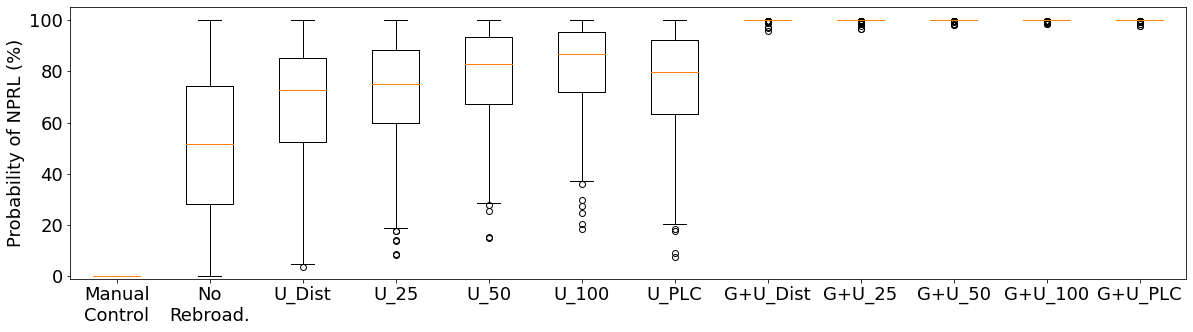

In [11]:
df_result = pd.read_csv("/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/results_new_Mar25/Prob_NPRL_NC_3_0-499_runs.csv")

plt.rcParams.update({'font.size': 18, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, ax = plt.subplots(1, 1, figsize=(20, 5))

# With one box plots for results from all USIs
ax.boxplot([df_result["Manual"].dropna().values, df_result["Waypoint_Only"].dropna().values, df_result["DV"].dropna().values, df_result["FP_25"].dropna().values,
            df_result["FP_50"].dropna().values, df_result["FP_100"].dropna().values, df_result["PM"].dropna().values, df_result["DV_GCS"].dropna().values,
            df_result["FP_25_GCS"].dropna().values, df_result["FP_50_GCS"].dropna().values, df_result["FP_100_GCS"].dropna().values, df_result["PM_GCS"].dropna().values],
            showmeans=False, labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC", "G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"],)

ax.set_ylabel("Probability of NPRL (%)")
ax.set_ylim(-1,105)

In [9]:
df_result["FP_50_GCS"].dropna().min(), df_result["PM_GCS"].dropna().min()

(67.2, 60.2)

In [34]:
print(df_result["FP_50_GCS"].dropna().min(), df_result["FP_100_GCS"].dropna().min(), df_result["PM_GCS"].dropna().min())

98.0 98.0 98.0


## Plot Results Manual Rebroadcasting

(0.0, 100.0)

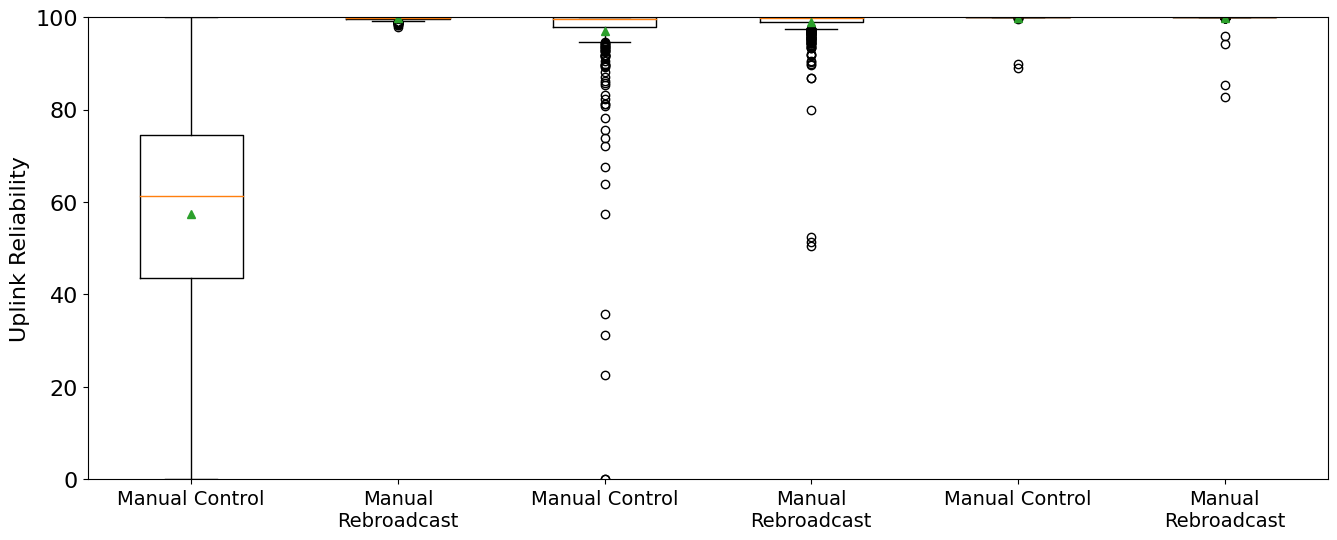

In [20]:
# CASES = ["uav_scenario_1_processed"]
# MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference"
# MANUAL_BR_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/Manual_Rebroadcast_Exp/TH_RL10ms_MaxBr7"

CASES = ["manet_scenario_1_processed"]
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference"
MANUAL_BR_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/Manual_Rebroadcast_Exp/TH_RL10ms_MaxBr7"

manual_df = compile_results(MANUAL_PATH, CASES, "Simulation_Results.csv")
manual_br_df = compile_results(MANUAL_BR_PATH, CASES)

# Plot box plot for Avg DL Reliability
avg_dl_rel_list = [manual_df["Total_Reliability_DL"].values*100, manual_br_df["Total_Reliability_DL"].values*100, manual_df["Total_Reliability_UL"].values*100, 
                   manual_br_df["Total_Reliability_UL"].values*100, manual_df["Total_Reliability_VID"].values*100, manual_br_df["Total_Reliability_VID"].values*100]
fig = plt.figure(figsize=(16, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(avg_dl_rel_list, showmeans=True, labels=["Manual Control", "Manual\nRebroadcast", "Manual Control", "Manual\nRebroadcast", "Manual Control", "Manual\nRebroadcast"])
plt.ylabel("Uplink Reliability")
plt.xticks(fontsize=14)
plt.ylim(0, 100)


(0.0, 100.0)

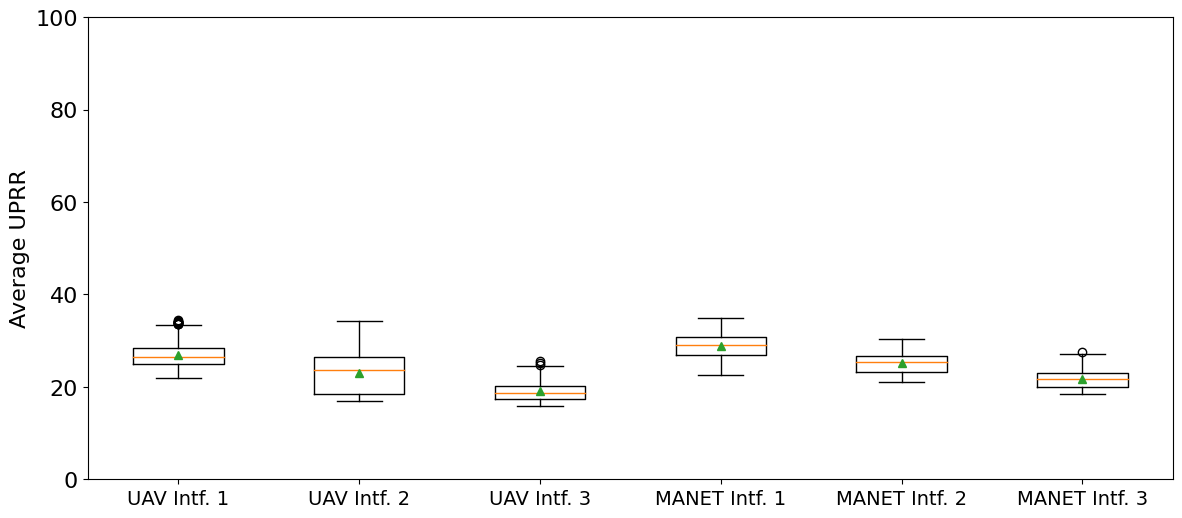

In [21]:
MANUAL_BR_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/Manual_Rebroadcast_Exp/TH_RL10ms_MaxBr7"

uav_0 = compile_results(MANUAL_BR_PATH, ["uav_scenario_0_processed"])
uav_1 = compile_results(MANUAL_BR_PATH, ["uav_scenario_1_processed"])
uav_2 = compile_results(MANUAL_BR_PATH, ["uav_scenario_2_processed"])
manet_0 = compile_results(MANUAL_BR_PATH, ["manet_scenario_0_processed"])
manet_1 = compile_results(MANUAL_BR_PATH, ["manet_scenario_1_processed"])
manet_2 = compile_results(MANUAL_BR_PATH, ["manet_scenario_2_processed"])


# Plot box plot for Avg DL UPRR
avg_dl_uprr_list = [uav_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, uav_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, 
                    uav_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, manet_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100,
                    manet_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, manet_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100]
fig = plt.figure(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(avg_dl_uprr_list, showmeans=True, labels=["UAV Intf. 1", "UAV Intf. 2", "UAV Intf. 3", "MANET Intf. 1", "MANET Intf. 2", "MANET Intf. 3"])
plt.ylabel("Average UPRR")
plt.xticks(fontsize=14)
plt.ylim(0, 100)